In [104]:
import os


def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn # To ignore some warnings from sklearn logistic regression
from sklearn.exceptions import ConvergenceWarning # To avoid logistic regression failing in case of perfect separation

import datetime
import numpy as np
from scipy.optimize import minimize # minimizing function for AIOLI
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import pandas as pd
from sklearn.linear_model import LogisticRegression # for classic logistic regression
from typing import Literal
from sklearn.neighbors import KDTree # For Knn for SMOTE

options={"disp": False} # To not get verbose from minimize function

# Global variables

In [105]:
default_n = 500
default_runs = 10
default_test_ratio = 0.5

# Algorithms

## Helper functions for algorithms

In [171]:
def sig(z):
    """ Sigmoid function that avoids overflow """
    if z < 0:
        return np.exp(z) / (1 + np.exp(z))
    else:
        return 1 / (1 + np.exp(-z))

In [172]:
# TODO : put in general algorithm function that if radius == NA then this is not done.
def project_onto_l2_ball(x,radius):
    """ Euclidean projection onto L2 ball"""
    norm = np.linalg.norm(x)
    if norm <= radius:
        return x
    return x * radius/norm

In [173]:
def calculate_OTB(array, method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None, p = 0.5):
    """ Weighted average function
    ----
    Parameters:
        p: Proportion of last observations to average over. Ex p = 0.3 means average over last 30% of observations.
    Methods:
        Suffix averaging: Average over last p percentage of observations.
        Uniform: Average over all iterates equally
        Last iterate: Consider only the last iterate.
        """
    n = len(array)
    # Check p is a proportion
    if p is None:
        p = 0.5
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    match method:
        case "suffix_averaging":
            i = round((1-p)*n)
            result = np.mean(array[i:], axis=0)
        case "last_iterate":
            last_iterate = n - 1
            result = array[last_iterate]
        case _: # Uniform is default
            result = np.mean(array, axis=0)

    return result

In [174]:
def log_loss(betas,data_x,data_y):
    """ Works for a vector of betas and a whole dataset """
    return np.sum(np.logaddexp(0,-data_y*np.inner(data_x,betas)))

In [175]:
def generate_x(n,d, correlated = False, means = None, sds = None, highly_correlated = False, seed = 40, standardized = False):
    seed_used = seed
    rng = np.random.default_rng(seed) # Random number generator
    x = []

    if sds is None:
        sds = rng.uniform(0.1,0.5,d)
    if means is None:
        means = [rng.normal(1,sd,1).item() for sd in sds]
    # Put variances in covariance matrix
    cov = np.diag(sds**2)

    if not correlated:
        x = rng.multivariate_normal(means,cov, size = n)
    if correlated:
        # Create off diagonal, triangular matrix
        off_diag = np.triu(rng.uniform(0,2, size = (d,d)))
        cov = cov + off_diag + off_diag.T
        x = rng.multivariate_normal(means,cov, size = n)
    if highly_correlated and d == 3:
        x1 = generate_x(n,1, seed = seed_used)
        x2 = x1 + rng.normal(2,1)
        x3 = x1 + x2
        x = np.concatenate((x1,x2,x3), axis = 1)

    if standardized:
        standardized_x = (x - np.mean(x, axis=0) ) / np.std(x, axis=0)
        x = standardized_x
    return x


In [176]:
np.tile([-1,1],10)

array([-1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1])

In [177]:
def generate_y(n,x, betas, seed = 40, plot = False, method: Literal["sigmoid", "sinusoidal", "quadratic", "sig(1/x)", "only_x1_x2"] | None = None):
    y = np.zeros(n)
    prob_y1 = np.zeros(n)
    rng = np.random.default_rng(seed) # Random number generator

    match method:
        case "sinusoidal":
            errors = rng.normal(0,0.1,n)
            prob_y1 = [(1/2)*np.sin(5*np.inner(x_t,betas) + e)+1/2 for x_t,e in zip(x,errors)]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "quadratic":
            prob_y1 = [sig(np.inner((x_t**2),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "sig(1/x)":
            prob_y1 = [sig(np.inner((1/x_t),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "only_x1_x2":
            x1_x2 = x[:,0:2]
            prob_y1 = [sig(np.inner(x1_x2_t,betas[0:2])) for x1_x2_t in x1_x2]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "alternating":
             y = np.tile([1,-1],round(n/2))

        case _: # Sigmoid function is default
            prob_y1 = [sig(np.inner(x_t,betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

    # Graphs
    if plot:
        for i in range(x.shape[1]):
            sns.scatterplot(x = x[:,i].flatten(), y = prob_y1)
            plt.title(f"P(Y=1) over x{i+1}")
            plt.show()

    return np.array(y)

In [178]:
def generate_data(setting, balanced = True, seed = 30, n = default_n, x_means = None, B = 4, a = 1, b = -1, plot_y = False, X_hazan = 1,d = 3, hyperparameter_analysis = False, betas = None):
    # Allocate space for variables
    x = []
    y = []
    betas = [] if betas is None else betas
    # betas = betas
    rng = np.random.default_rng(seed)
    hazan_py1 = 0
    # Define x means based on balanced or unbalanced setting
    x_means_simulation = [1,-2,0.83] if x_means is None else x_means
    test_size = round(default_test_ratio*n)
    full_n = n+test_size

    # Generate data according to setup
    match setting:
        case "well specified":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if None in betas or len(betas) == 0:
                betas = [0.4,-0.3,-1.2] if balanced else [-1,-2.5,2.6] # average sigmoid balanced: 0.5, unbalanced : 0.002

            y = generate_y(full_n,x,betas = betas, seed = seed)

        case "high dimensional":
            # Define betas and x means to fit high dimensionality
            betas = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7] if balanced else [2,1.8,-3.7,1.4,0.5,0.2,-1,-0.3,2.2,0.1,0.6,1.9,-1.4,2.7,-1.4,0.5,-1,3.2,1.5,-1.5,-2.4,1.2,3.6,-0.8,-1.7]
            x_means_simulation = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]
            if hyperparameter_analysis:
                x_means_simulation = [2, -4.2, 1, 2.4, -1.6, -3.8, -5, -4.1,0.2, 6, 1, -3, 4.2, -2.1,5.6, -6,6.3, 4.5, -1.3, 6.2, 2.3, 1.4, 4, -2, 2] if balanced else [2, -4.2, 1, 2.4, -1.6, -3.8, -5, -4.1,0.2, 6, 1, -3, 4.2, -2.1,5.6, -6,6.3, 5.8, -1.3, 6.2, 2.3, 1.4, 4, -2, 2]
            # Generate x again for the high dimensional setting
            x = generate_x(full_n,25, means = x_means_simulation, seed = seed)
            y = generate_y(full_n,x,betas = betas, seed = seed)
        case "sinusoidal":
            x_means_simulation = [-1.9,1.5,0.4]
            betas = [1.8,-0.6,1.4] if balanced else [0.8,-0.9,1.8]
            x = generate_x(full_n,3, means = x_means_simulation, seed = seed)
            y = generate_y(full_n,x,betas = betas, seed = seed, method = "sinusoidal", plot = plot_y)
        case "quadratic":
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            betas = [-1.44,0.5,-0.8] if balanced else [0.9,1.3,-1.2]
            y = generate_y(full_n,x,betas = betas, seed = seed, method = "quadratic")
        case "hazan 1-dimensional":
            B = np.log(full_n)
            # B = 300
            # epsilon = (B**(2/3))/(n**(2/3))
            epsilon = 0.01
            theta = np.sqrt(epsilon)/B
            hazan_py1 = theta/2 + X_hazan*epsilon/B
            xy = rng.choice([[1- theta/2,a],[theta,b]], size = full_n, p = [theta/2 + X_hazan*epsilon/B, 1- (theta/2 + X_hazan*epsilon/B)])
            x = xy[:,0]
            y = xy[:,1]
            x = x.reshape(full_n,1)
        case "binomial_x":
            d = 1
            p_i = rng.uniform(0.1,0.9, d)
            n_i = rng.uniform(1,10, d).astype(int)
            x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
            # Just to have the correct d later
            x_means_simulation = np.zeros(d)
            # betas = rng.uniform(size = d,low = -0.5,high = 0.8)
            betas = rng.uniform(-0.8,0.8,d)
            av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            # Ensure balance levels
            if balanced:
                threshold = 0.4
                while  av_sigma < threshold or av_sigma > threshold +0.2:
                    p_i = rng.uniform(0.1,0.9, d)
                    n_i = rng.uniform(1,10, d).astype(int)
                    x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
                    betas = rng.uniform(-0.8,0.8,d)
                    av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            elif not balanced:
                threshold =  1 - 1 / n - 0.002
                # Sample betas again if its not unbalanced enough
                while  av_sigma < threshold :
                    p_i = rng.uniform(0.1,0.9, d)
                    n_i = rng.uniform(1,10, d).astype(int)
                    x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
                    betas = rng.uniform(-0.8,0.8,d)
                    av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            prob_y1 = [sig(np.inner(xt,betas)) for xt in x]
            y = np.array([rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1])

            if d==1: x = x.reshape(full_n,1)
        case "highly correlated x":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed, highly_correlated = True)
            if None in betas or len(betas) == 0:
                betas = [2.4,0.8,-1.2] if balanced else [2.4,1.5,-1.2] # average sigmoid balanced: 0.5, unbalanced : 0.002

            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y)
        case "alternating":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if None in betas or len(betas) == 0:
                betas = [2.4,0.8,-1.2] if balanced else [2.4,1.5,-1.2] # average sigmoid balanced: 0.5, unbalanced : 0.002
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "alternating")

    if setting == "hazan 1-dimensional":
        print(f"{n} (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of {hazan_py1}")
    else:
        d = len(x_means_simulation)
        av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
        av_sin = round(np.mean( [(1/2)*np.sin(5*np.inner(x,b)) +1/2 for xb in np.inner(x,betas)]),3)
        print(f"{n} (training) samples were generated in the {setting} {"balanced" if balanced else "unbalanced"} setting. Using {d} variable(s), with an average P(Y=1) of {av_sin if setting == "sinusoidal" else av_sigma}")

    # Make train/test split

    x_train = x[test_size:]
    y_train = y[test_size:]
    x_test = x[:test_size]
    y_test = y[:test_size]

    return x_train, y_train, x_test, y_test

In [179]:
a,b,c,d = generate_data("alternating", n =100, balanced = True)
# [1,2,3,4][:2]

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.454


In [180]:
len(a)
# sns.scatterplot(x = a[:,0], y = a[:,1])

100

In [181]:
a = [None,]
if None in a:
    print("hi")

hi


In [182]:
a,b,c,d = generate_data("hazan 1-dimensional", n =500)


500 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.009063343882785638


In [183]:
a = generate_x(100,3, means = [2,2,1])
generate_y(100, x = a, betas = [2,1,0.1],method = "sinusoidal" )


array([-1,  1, -1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,  1,  1,  1, -1,
        1, -1,  1, -1,  1,  1, -1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1, -1, -1,  1,  1,
        1,  1,  1,  1, -1,  1, -1, -1,  1, -1, -1, -1,  1, -1,  1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1,  1, -1,  1,  1,
       -1, -1, -1, -1,  1, -1, -1, -1, -1,  1, -1, -1, -1, -1,  1])

### Test functions

In [184]:
hola = generate_x(200,2, means = [0.5,1.2])

In [185]:
adios = generate_y(200,generate_x(200,2, means = [0.5,1.2]),[0.1,0.3], method = "sinusoidal", plot = False)
# adios2 = generate_y(200,generate_x(200,3, means = xs_balanced),bs_balanced, method = "sinusoidal", plot = True)
print(sum(adios == 1))
print(sum(adios == -1))

173
27


## Online Gradient Descent

In [228]:
def online_gd(data_y, data_x, OTB_method = None, OTB_average_proportion = None):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.

    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)
    y_hat = np.zeros(n)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        y_hat[t] = sig(np.inner(betas[t],xt))

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0

    # Store endtime
    end_time =  datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas,
        "predictions": y_hat
    }


### Testing ODG

In [187]:
#ogd = online_gd(n = 40,d = 3,data_y = y,data_x = x,B = 40)

## AIOLI

In [188]:
class AIOLI:
    def __init__(self):
        self.first_sum  = []
        self.etas_gradients = []
        self.x0 = [] # Initializer for minimizing algorithm
        self.reg_lambda = 0
        self.train_size = 0
        self.d = 0
        self.n = 0

    # Define function to minimize for AIOLI
    @staticmethod # Because I dont use the self
    def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
        l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
        # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
        result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
        return result

    def new_point_loss(self,X,Y, OTB_method):
        convergence_new = 0
        beta_hat = np.zeros((self.train_size,self.d))
        first_sum  = np.zeros(self.d)
        etas_gradients = np.zeros((self.d,self.d))
        for t in range(self.train_size):
            # Minimize using data up until t-1
            result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
            beta_hat[t] = result.x
            convergence_new += result.success
            # Update minimization elements for next round
            first_sum += self.first_sum[t]
            etas_gradients += self.etas_gradients[t]

        # Get OTB
        big_beta = calculate_OTB(beta_hat, OTB_method)

        # Suffer loss
        loss_point = np.logaddexp(0,-Y*np.inner(X,big_beta))

        return loss_point

    def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
        start_time = datetime.datetime.now()
        new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
        end_time = datetime.datetime.now()
        return{
                "runtime" : (end_time - start_time).total_seconds(),
                "loss" : sum(new_losses)
            }


    def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b", dynamic_B = False):
        """AIOLI
        This is the function to run AIOLI.

        Parameters
        ---------
        data_y : ndarray
            Vector with outcome(y) values. Dimensions: n x 1
        data_x: ndarray
            Array with independent variables. Dimensions: n x d
        B: float
            Radius of the L2 ball constraint for the parameter vector beta
        X: float
            Radius of the L2 ball constraint for the feature vector x"""
        # Record start time
        start_time = datetime.datetime.now()

        # Get data dimensions
        self.n = data_x.shape[0]
        n = self.n
        self.d = data_x.shape[1]
        d = self.d
        self.x0 = np.zeros(d) # Initializer for minimizing algorithm
        self.train_size = n
        # Initialize vectors for storage
        betas = np.zeros((n, d))
        ys = np.zeros(n)
        y_hats = np.zeros(n)
        loss = np.zeros(n)
        etas = np.zeros(n)
        gradients = np.zeros((n, d))
        self.reg_lambda = 1 / (B**2)

        # Keep sums for loss functions
        self.first_sum  = np.zeros((n, d))
        self.etas_gradients = np.zeros((n,d,d))
        first_sum  = np.zeros(d)
        etas_gradients = np.zeros((d,d))

        # Track convergence
        convergence = 0
        minimizer_gradient = 0

        # Run Algorithm
        for t in range(n):
            # Get context vector
            xt = data_x[t]

            # Update beta parameter
            # noinspection PyTypeChecker # This is to avoid the underlining which
            if t == 0: # Initialize to 0 for first round
                betas[t] = np.zeros(d)
            else:
                result = minimize(self.parameter_function_AIOLI,
                                  np.zeros(d),
                                  method = minimize_method,
                                  args=(xt, self.reg_lambda,first_sum, etas_gradients),
                                  options = {"maxiter":100000}
                                  )
                betas[t] = result.x
                convergence += result.success
                minimizer_gradient += np.linalg.norm(result.jac)

            # # Project beta onto set
            # betas[t] = project_onto_l2_ball(beta_tilde,B)
            # betas[t] = self.x0

            # Generate prediction
            y_hats[t] = np.inner(xt,betas[t])

            # Observe true y from data
            ys[t] = data_y[t]

             # Compute gradient
            gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

            # Estimate eta
            etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

            # Suffer loss
            loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))

            # Compute elements for AIOLI loss function

            fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
            eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
            self.first_sum[t] = fs
            self.etas_gradients[t] = eg
            first_sum += fs
            etas_gradients += eg
            # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.

            # Dynamic Hyperparameter tuning
            if dynamic_B:
                B = max(B, np.linalg.norm(betas[t]))

        # for loop ends

        # Get Batch estimate
        betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

        # Get Batch estimate loss
        loss_OTB = log_loss(betas_OTB,data_x, data_y)

        end_time = datetime.datetime.now()

        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "Total_Loss" : loss_OTB,
            "Online_Loss" : sum(loss),
            "Batch_estimate": betas_OTB,
            "All_Betas": betas,
            "convergence" : convergence,
            "minimizer_gradient" : minimizer_gradient
        }



### Testing AIOLI

AIOLI convergence check

In [189]:
# aioli_model = AIOLI()
# aioli_results_nondynamic = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 1, minimize_method = "l-bfgs-b", dynamic_B = False)
# aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

In [190]:
# aioli_model = AIOLI()
# aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = "l-bfgs-b", dynamic_B = True)
# aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

In [191]:
# minimization_methods = ["l-bfgs-b",'bfgs',"CG"]
#
# for method in minimization_methods:
#     aioli_model = AIOLI()
#     aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 5, minimize_method = method)
#     print(f"Method: {method}")
#     print(f"convergence: {aioli_results["convergence"]}")
#     print(f"minimizer_gradient: {aioli_results["minimizer_gradient"]}")
#     print(f"Online loss: {aioli_results["Online_Loss"]}")


In [192]:
# aioli_model.new_data_loss(new_data_x = x_test, new_data_y = y_test, OTB_method = "uniform")

## Ada Grad

In [193]:
def online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = betas[t,i] - eta_ti*gradient[i]
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [194]:
def projected_online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)
    b_min = - B_vector / 2
    b_max = B_vector / 2

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = max(min(betas[t,i] - eta_ti*gradient[i],b_min[i]),b_max[i])
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [195]:
# x = generate_x(150,3, means= [2,2,1])
# betas = [2,20,-4.2]
# y = generate_y(150,x,betas = betas)
#
# x_train = x[:100]
# y_train = y[:100]
# x_test = x[100:]
# y_test = y[100:]
#
# standardized_x_train = (x_train - np.mean(x_train, axis=0) ) / np.std(x_train, axis=0)
#x_train = standardized_x_train

In [196]:
# ag_trial = online_AdaGrad(y_train, x_train, np.repeat(40/13,3))
# ag_trial
# print(log_loss(ag_trial["Batch_estimate"],x_test,y_test))
# ag_u = calculate_OTB(ag_trial["All_Betas"], "uniform")
# ag_s  = calculate_OTB(ag_trial["All_Betas"], "suffix_averaging")
# ag_li  = calculate_OTB(ag_trial["All_Betas"], "last_iterate")
# print(f"{log_loss(ag_u,x_test,y_test)}, {log_loss(ag_s,x_test,y_test)},  {log_loss(ag_li,x_test,y_test)}" )


In [197]:
# og_trial = online_gd(y_train, x_train, 40)
# og_trial
# log_loss(og_trial["Batch_estimate"],x_test,y_test)

Hyperparemeter tuning Ada Grad

In [198]:
# B_values_adagrad = [x for x in range(1, 60, 4)]
# loss_B_adagrad = np.zeros(len(B_values_adagrad))
#
# for i in range(len(B_values_adagrad)):
#     adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(B_values_adagrad[i],3))
#     ag_u = calculate_OTB(adagrad["All_Betas"], "uniform")
#     ag_s  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
#     ag_li  = calculate_OTB(adagrad["All_Betas"], "last_iterate")
#     print(f"{log_loss(ag_u,x_test,y_test)}, {log_loss(ag_s,x_test,y_test)},  {log_loss(ag_li,x_test,y_test)}" )
#
#     loss_B_adagrad[i] = log_loss(ag_u, x_test, y_test)


In [199]:
# Create DataFrame for seaborn
# df = pd.DataFrame({
#     'B_value': B_values_adagrad,
#     'Loss': loss_B_adagrad
# })
#
# # Line plot with markers
# sns.lineplot(data=df, x='B_value', y='Loss', marker='o', markersize=10,
#              linewidth=2, color='steelblue')

## Logistic Regression

In [200]:
def classic_logistic_regression(data_x, data_y):
    # Using safe implementation where if data is perfectly separable, then it's just fit minimizing the logistic loss.
    start_time = datetime.datetime.now()

    try:
        logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=10000)
        logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        # Single class case: fit manually using scipy minimize on the logistic loss
        def logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores))

        result = minimize(logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Logistic regression was fit manually")


    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [201]:
x_train, y_train, x_test, y_test = generate_data(setting = "well specified", balanced = False, seed = 42, n =50)

50 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.996


In [202]:
y_train

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1])

In [203]:
b = classic_logistic_regression(x_train,y_train)["Batch_estimate"]
log_loss(b,x_test,y_test)

Logistic regression was fit manually


np.float64(1.6750741559055265e-06)

In [204]:
# def classic_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty=None, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Ridge Logistic Regression

In [205]:
def ridge_logistic_regression(data_x, data_y, reg_lambda=1.0):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l2', C=1/reg_lambda, fit_intercept=False, max_iter=10000)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def ridge_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.linalg.norm(b)**2

        result = minimize(ridge_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Ridge LR was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [206]:
# def ridge_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty="l2", random_state=1, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Lasso Logistic Regression

In [207]:
def lasso_logistic_regression(data_x, data_y, reg_lambda=1.3):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l1', C=1/reg_lambda, fit_intercept=False, max_iter=10000)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def lasso_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.abs(np.linalg.norm(b, ord = 1))

        result = minimize(lasso_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Lasso LR was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

## Sample Minmax Predictor (SMP)

In [208]:
class sample_minmax_predictor():
    def __init__(self,data_x, data_y):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = sig(1*np.inner(beta_hat_y1,new_x)) / ( sig(np.inner(beta_hat_y1,new_x)*1) + sig(np.inner(beta_hat_y_1,new_x)*(-1)) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))
        # loss_point = np.logaddexp(0,-new_y*np.inner(new_x,beta_hat_y1))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : sum(new_losses),
            "loss_t" : new_losses
        }


### Testing SMP

In [209]:
# smp = sample_minmax_predictor(x_train, y_train)
# smp.get_new_loss(x_test, y_test)

## Ridge-regularized SMP

In [210]:
class ridge_sample_minmax_predictor():
    def __init__(self,data_x, data_y, reg_lambda = 0.1):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0
        self.n = 0
        self.reg_lambda = reg_lambda

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = (np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))) / (self.n + 1) + (self.reg_lambda/2) * np.linalg.norm(b)**2
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = (sig(1*np.inner(beta_hat_y1,new_x)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2)) / ( ( sig(np.inner(beta_hat_y1,new_x)*1) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2) )  + ( sig(np.inner(beta_hat_y_1,new_x)*(-1)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y_1)**2) ) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        self.n = self.data_x.shape[0]
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : sum(new_losses),
            "loss_t" : new_losses
        }


## SMOTE

In [211]:
class SMOTE():
    def __init__(self,data_x, data_y ,seed = 40, k = 1, S = 100):
        """ This class performs SMOTE on a dataset. The apply_smote method returns the new data with synthetic samples """
        self.seed = seed
        self.rng = np.random.default_rng(self.seed)
        self.d = 0
        self.k = k
        self.Xmin = []
        self.new_data_y = []
        self.synthetic = [] # array to store synthetic samples
        self.new_i = 0 # variable to keep indices of new synthetic samples. Initialize to 0
        self.data_x = data_x
        self.data_y = data_y
        self.M = 0
        self.S = S
        self.oneclass = False

    def get_min_class_x(self):
        # Get proportion of y = 1
        prop_y1 = np.sum(self.data_y == 1) / len(self.data_y)
        # Get the value of y that is minority
        y_minority = 1 if prop_y1 < 0.5 else -1
        self.oneclass = True if prop_y1 == 1 or prop_y1 == 0 else False
        self.M = np.sum(self.data_y == y_minority)
        # Get only x values for which the outcome is part of the minority
        self.Xmin = self.data_x[self.data_y == y_minority]
        n_new_samples = int((self.S/100)*self.M)
        new_minority_ys = np.full(n_new_samples,y_minority)
        self.new_data_y = np.append(self.data_y,new_minority_ys)
        return True if prop_y1 == 0.5 else False

    def populate(self, s_j, i, nn_indices):
        while s_j != 0:
            # Chose one of the k nearest neighbours of i
            ss = self.rng.integers(0,self.k)
            # Now for every attribute
            for j in range(self.d):
                diff = self.Xmin[nn_indices[ss]][j] - self.Xmin[i][j]
                gap = self.rng.uniform(0,1)
                self.synthetic[self.new_i][j] = self.Xmin[i][j] + gap*diff
            # end for
            self.new_i += 1
            s_j -= 1

    def apply_smote(self):
        """Synthetic Minority Oversampling Technique (SMOTE)
        Parameters
        ---------
        Xmin : array
            Array of minority class samples
        M: int
            Number of minority class samples
        S: int
            Percentual amount of SMOTE
        """

        # Get the Xmin (x values with outcome from minority class)
        no_minority = self.get_min_class_x()

        if no_minority:
            print("Dataset is balanced")
            return self.data_x,self.data_y
        if self.oneclass:
            print("Dataset only has one class")
            return self.data_x,self.data_y

        # If S is less than 100%, randomize the minority class samples as only a random percent of them will be SMOTEd
        if self.S < 100:
            self.M = (self.S/100)*self.M
            self.S = 100
        # Get number of synthetic samples
        s = int(self.S/100)
        # Get number of attributes
        self.d = self.Xmin.shape[1]
        # Assign correct dimensions to synthetic samples array
        self.synthetic = np.zeros((s*self.M,self.d))

        # Make k nearest neighbors tree
        tree = KDTree(self.Xmin)

        # Get synthetic samples for each datapoint
        for i in range(self.M):
            nn_indices = tree.query(self.Xmin[i:i+1], k = self.k)[1][0]  # First index [1] is to get only the item with the indices, that gives a dataframe of 1 row. Second index [0] is to get that row and simply get an array of the indices
            self.populate(s,i,nn_indices)
        new_data_x = np.concatenate((self.data_x, self.synthetic))
        return new_data_x,self.new_data_y



In [212]:
# sm = SMOTE(data_x = a, data_y = b,S = 100)
# smote_result_x, smote_result_y = sm.apply_smote()

In [213]:
# smote_result_x.shape

In [214]:
# len(smote_result_y)

In [215]:
# classic_logistic_regression(data_x=smote_result_x, data_y=smote_result_y)

 # Hyperparameter selection

In [48]:
def hyperparameter_analysis(setting, algorithm, evaluated_parameter, balanced = True, seed = 30, n = 200, x_means = None, X_hazan = 1, d =3, betas = None):
    # Generate data
    x_train, y_train, x_test, y_test = generate_data(setting, balanced, seed, n, x_means, hyperparameter_analysis = True,
                                                     X_hazan = X_hazan,
                                                     d = d,
                                                     betas = betas)
    d = x_train.shape[1]
    # Allocate variables
    values = []
    loss = []
    # Run model

    match evaluated_parameter:
        case "B":
            match algorithm:
                case "AIOLI":
                    values = [x for x in range(1,60,10)]
                    loss = np.zeros(len(values))
                    for i in range(len(values)):
                        aioli_model = AIOLI()
                        aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = values[i], minimize_method = "l-bfgs-b", dynamic_B = False)
                        loss[i] = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
                case "ADAGRAD":
                    values = [x for x in range(1, 60, 4)]
                    loss = np.zeros((len(values),3))

                    for i in range(len(values)):
                        adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(values[i],d))
                        ag_u = calculate_OTB(adagrad["All_Betas"], "uniform")
                        ag_s  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
                        ag_li  = calculate_OTB(adagrad["All_Betas"], "last_iterate")
                        loss[i] = [log_loss(ag_u,x_test,y_test),log_loss(ag_s,x_test,y_test),log_loss(ag_li,x_test,y_test)]

        case "X":
            values = [x for x in range(1,160,25)]
            loss = np.zeros(len(values))

            for i in range(len(values)):
                aioli_model = AIOLI()
                aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = values[i], B = 5, minimize_method = "l-bfgs-b")
                loss[i] = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
    # Graph
    match algorithm:
        case "AIOLI":
            df = pd.DataFrame({
                evaluated_parameter: values,
                'Loss': loss
            })

            # Line plot with markers
            sns.lineplot(data=df, x= evaluated_parameter, y='Loss', marker='o', markersize=10,
                         linewidth=2, color='steelblue').set_title(f"AIOLI: {setting} setting")
            plt.show()
            plt.close()
        case "ADAGRAD":
            df = pd.DataFrame(loss)
            df["B"] = values
            df = df.rename(columns={0: "uniform", 1: "suffix", 2: "last_iterate"})

            fig, axs = plt.subplots(ncols=3, sharey=True)
            # Plot each one
            sns.lineplot(data=df, x="B", y='uniform', marker='o', markersize=10,
                         linewidth=2, color='steelblue', ax=axs[0])
            axs[0].set_title("uniform")
            axs[0].set_ylabel("Loss")  # only leftmost gets ylabel

            sns.lineplot(data=df, x="B", y='suffix', marker='o', markersize=10,
                         linewidth=2, color='steelblue', ax=axs[1])
            axs[1].set_title("suffix")
            axs[1].set_ylabel("")  # remove ylabel

            sns.lineplot(data=df, x="B", y='last_iterate', marker='o', markersize=10,
                         linewidth=2, color='steelblue', ax=axs[2])
            axs[2].set_title("last_iterate")
            axs[2].set_ylabel("")  # remove ylabel
            # # Create subplots
            # fig, axs = plt.subplots(ncols = 3)
            # # Plot each one
            # sns.lineplot(data=df, x= "B", y='uniform', marker='o', markersize=10,
            #                  linewidth=2, color='steelblue', ax = axs[0]).set_title("uniform")
            # sns.lineplot(data=df, x= "B", y='suffix', marker='o', markersize=10,
            #                  linewidth=2, color='steelblue', ax = axs[1]).set_title("suffix")
            # sns.lineplot(data=df, x= "B", y='last_iterate', marker='o', markersize=10,
            #                  linewidth=2, color='steelblue', ax = axs[2]).set_title("last_iterate")
            # Empty their axis labels
            for ax in axs:
                ax.set_xlabel('')
                ax.set_ylabel('')
            # Make general axis labels
            fig.supxlabel("B", size=12)
            fig.supylabel("Loss", size=12)
            fig.suptitle(f"Ada Grad: {setting} setting", size=16)
            plt.show()
            plt.close()
    return


In [156]:
settings = ["well specified", "hazan 1-dimensional", "quadratic", "binomial_x"]

## Hyperparameter analysis

In [157]:
alt_xmeans_balanced_1 = [-2,-0.7,-0.5]
alt_xmeans_balanced_2 = [33,-12,14]
alt_xmeans_unbalanced_1 = [-3,2.7,1.8]
alt_xmeans_unbalanced_2 = [34,20,10]
sig(np.inner([-2],[-0.1]))

np.float64(0.549833997312478)

### AIOLI "B"

In [158]:
# for setting in settings:
#     hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = [-2], d = 1, betas = [-0.1])

In [159]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501


KeyboardInterrupt: 

In [ ]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_balanced_2)

In [ ]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

In [ ]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

### AIOLI "X"

In [ ]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_balanced_1)

In [ ]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_balanced_2)

In [ ]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

In [ ]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

### Ada Grad "B"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501


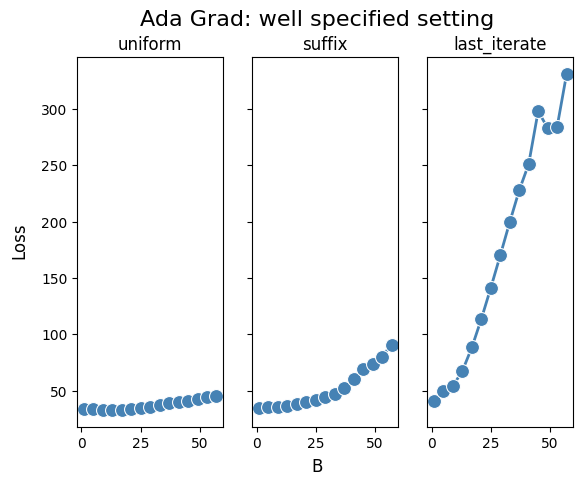

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305


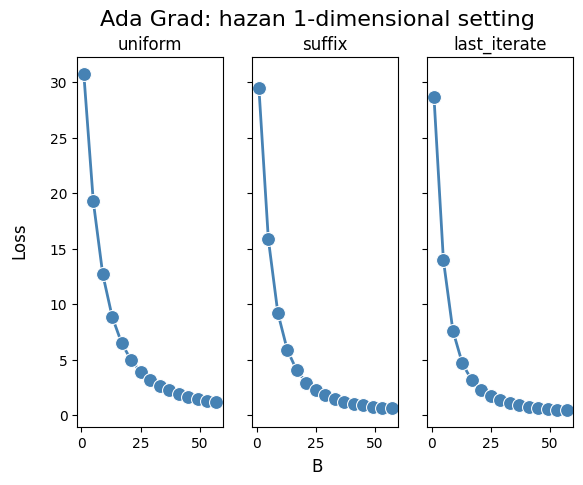

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946


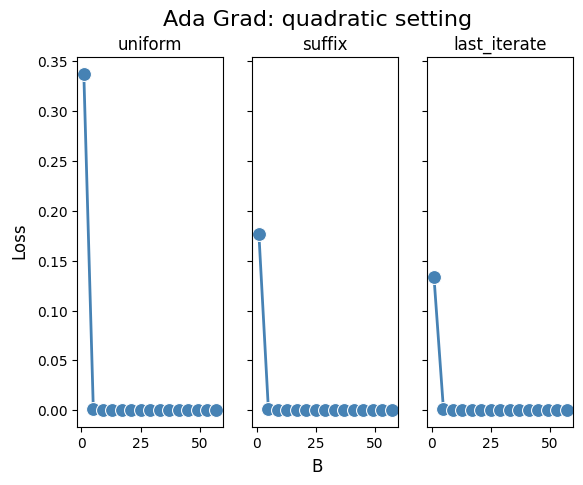

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


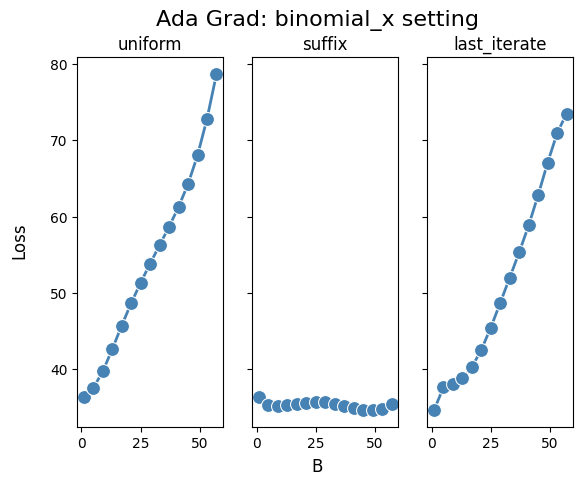

In [176]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498


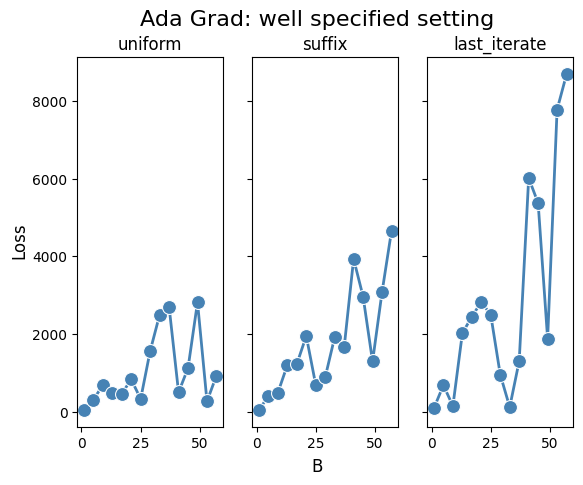

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305


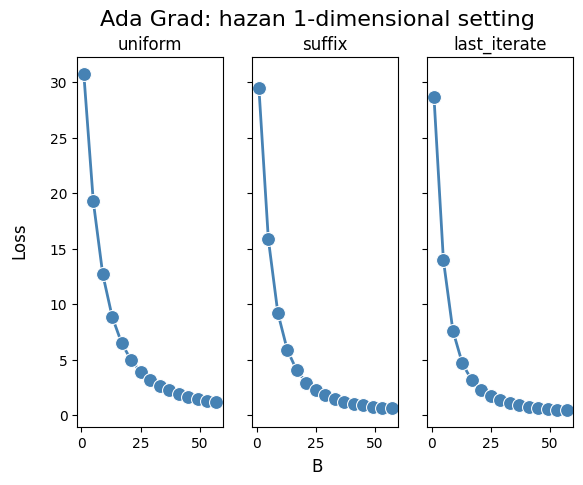

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


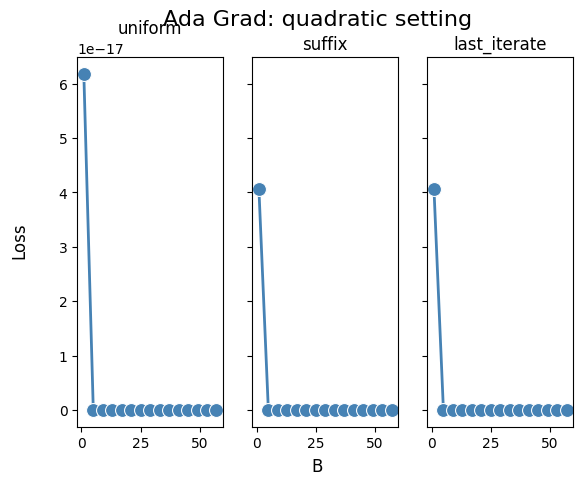

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


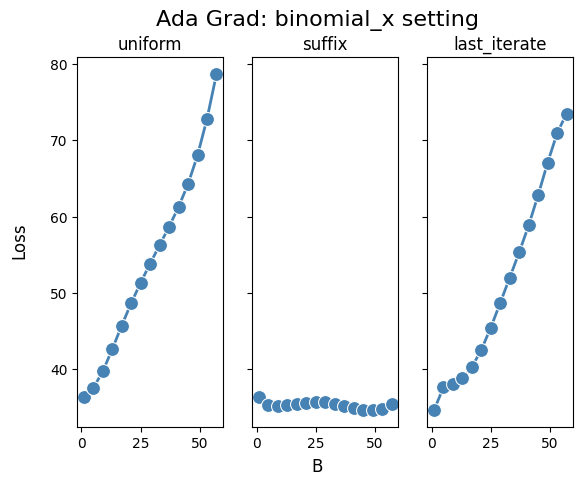

In [173]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.701


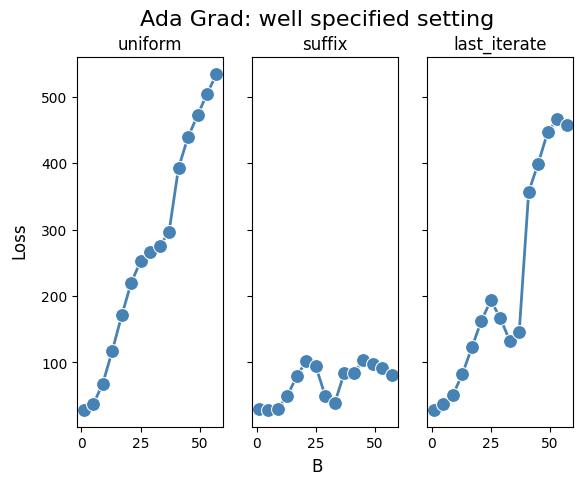

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204


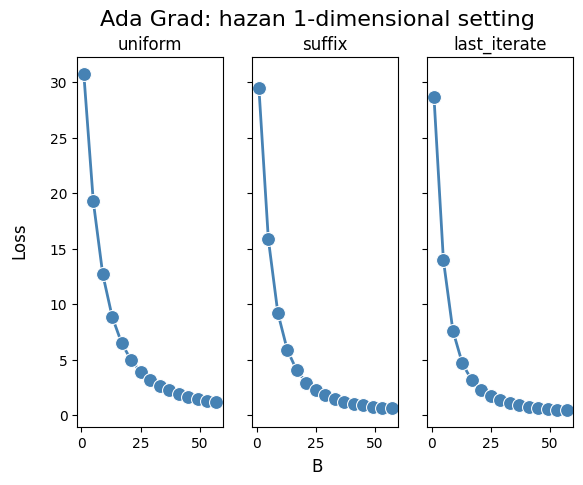

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.212


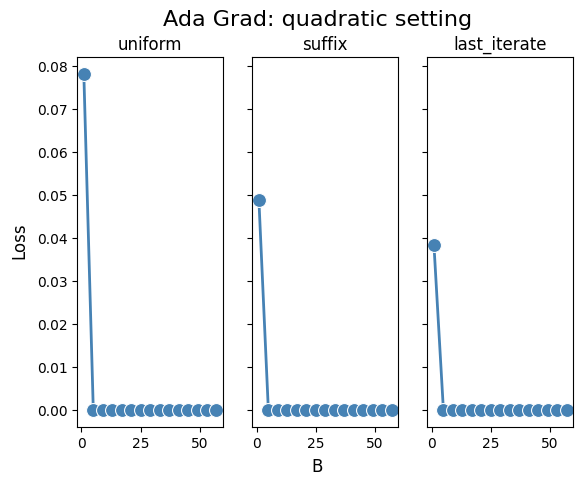

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.996


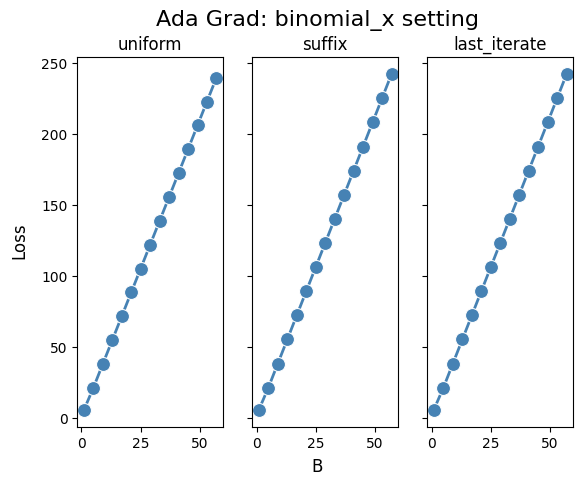

In [175]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


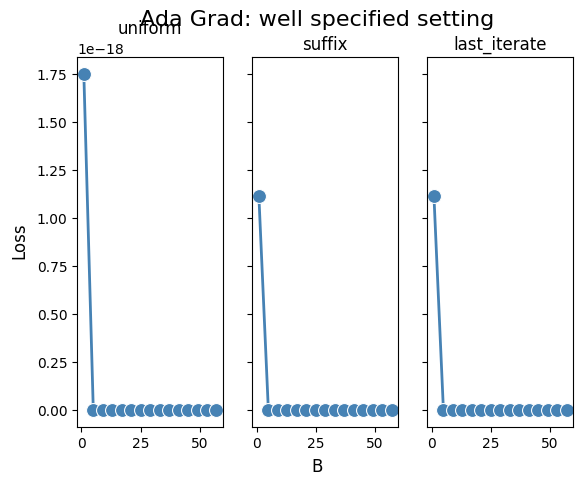

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204


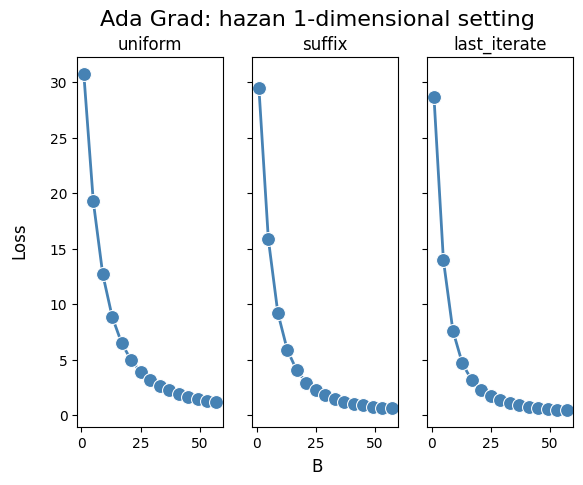

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 1.0


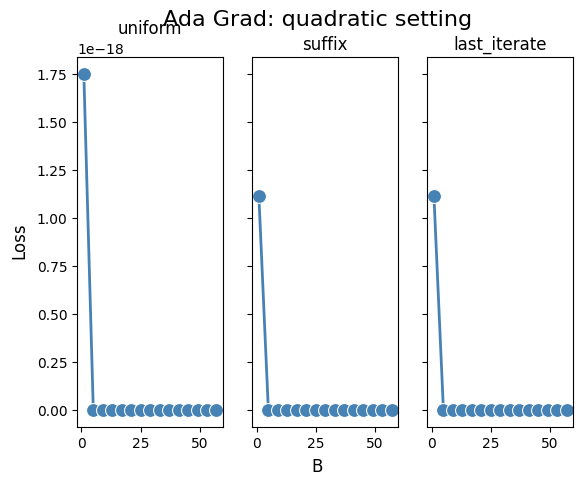

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.996


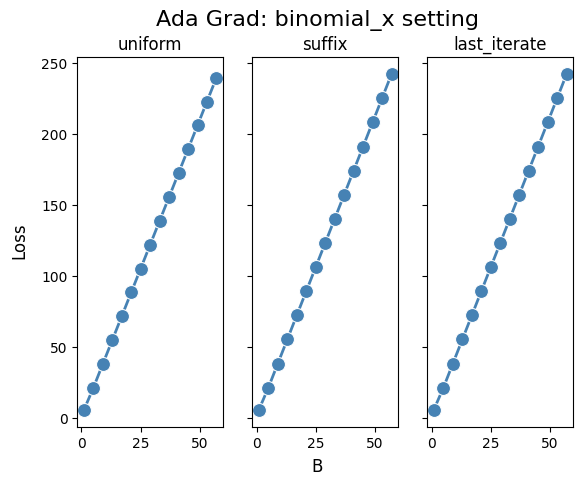

In [174]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

# Functions for simulations

## Data class for specifying simulation configuration

In [217]:
default_B = 20
default_X = 20
default_B_Adagrad = 5
@dataclass
class SimulationConfig:
    sim_betas: list =  None,
    # Default is well specified
    sim_setting: str =  "well specified"
    sim_balanced: bool = True
    runs: int = default_runs
    n: int = default_n
    d: int = 3
    data_seed: int = 40
    # betas: list = field(default_factory=lambda: [2,0.1,-4.2]) # This is to create a new list every time.
    # x_means: list = field(default_factory=lambda: [2,2,1])
    # These values of betas and x_means guarantee a P(Y=1) = 0.5, hence balanced classes.
    B: int = default_B
    X: int = default_X
    test_ratio: float = default_test_ratio
    minimize_method: str = "l-bfgs-b"
    y_method: str = "sigmoid"
    X_hazan: int = 1

## Function to run simulations and get results

In [225]:
def run_simulation(cfg: SimulationConfig = None):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    # betas = cfg.betas
    # x_means = cfg.x_means
    B = cfg.B
    X = cfg.X
    # test_ratio = cfg.test_ratio
    minimize_method = cfg.minimize_method
    # y_method = cfg.y_method
    data_seed = cfg.data_seed
    sim_setting = cfg.sim_setting
    sim_balanced = cfg.sim_balanced
    X_hazan = cfg.X_hazan
    sim_betas = cfg.sim_betas

    # results_all = []
    test_set_results = []
    y_counts = []
    start_time = datetime.datetime.now()

    # Store y values to use later
    all_y_trains = {}
    all_y_tests = {}

    for i in range(runs):
        x_train, y_train, x_test, y_test = generate_data(setting = sim_setting,
                                                             balanced = sim_balanced,
                                                             n = n,
                                                             seed = data_seed + i,
                                                             d = d,
                                                             X_hazan = X_hazan,
                                                             betas = sim_betas)

        # Store y counts to evaluate balance level later
        y_counts.append({
            "count_1": int(np.sum(y_train == 1)),
            "count_minus1": int(np.sum(y_train == -1))
        })

        # Store y values for later inspection
        all_y_trains[f"run_{i+1}"] = y_train.copy()
        all_y_tests[f"run_{i+1}"] = y_test.copy()

        # Get SMOTE dataset for unbalanced cases
        sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
        smote_x, smote_y = sm.apply_smote()

        # Run algorithms
        ogd = online_gd(data_y=y_train, data_x=x_train)
        adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(default_B_Adagrad,d))
        aioli_model = AIOLI()
        ai = aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=default_B, minimize_method = minimize_method)
        classic_LR = classic_logistic_regression(data_x=x_train, data_y=y_train)
        ridge_LR = ridge_logistic_regression(data_x=x_train, data_y=y_train)
        lasso_LR = lasso_logistic_regression(data_x=x_train, data_y=y_train)
        smp = sample_minmax_predictor(x_train, y_train)
        ridge_smp = ridge_sample_minmax_predictor(x_train, y_train)
        classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)

        # OTB estimates
        # OGD
        OGD_OTB_uniform = calculate_OTB(ogd["All_Betas"], "uniform")
        OGD_OTB_Suffix  = calculate_OTB(ogd["All_Betas"], "suffix_averaging")
        OGD_OTB_lastit  = calculate_OTB(ogd["All_Betas"], "last_iterate")
        # AdaGrad
        adagrad_OTB_uniform = calculate_OTB(adagrad["All_Betas"], "uniform")
        adagrad_OTB_Suffix  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
        adagrad_OTB_lastit  = calculate_OTB(adagrad["All_Betas"], "last_iterate")

        ############################## TEST RESULTS ##############################
        # OGD
        loss_OGD_uniform_test = log_loss(OGD_OTB_uniform, x_test, y_test)
        loss_OGD_Suffix_test  = log_loss(OGD_OTB_Suffix,  x_test, y_test)
        loss_OGD_lastit_test  = log_loss(OGD_OTB_lastit,  x_test, y_test)

        # Adagrad
        loss_adagrad_uniform_test = log_loss(adagrad_OTB_uniform, x_test, y_test)
        loss_adagrad_Suffix_test  = log_loss(adagrad_OTB_Suffix,  x_test, y_test)
        loss_adagrad_lastit_test  = log_loss(adagrad_OTB_lastit,  x_test, y_test)

        # AIOLI
        loss_AIOLI_uniform_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
        loss_AIOLI_Suffix_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"]
        loss_AIOLI_lastit_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"]

        # Logistic Regression
        loss_LR_test = log_loss(classic_LR["Batch_estimate"], x_test, y_test)
        loss_LR_smote_test = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
        loss_LR_Ridge_test = log_loss(ridge_LR["Batch_estimate"],   x_test, y_test)
        loss_LR_Lasso_test = log_loss(lasso_LR["Batch_estimate"],   x_test, y_test)

        # SMP
        smp_result = smp.get_new_loss(x_test, y_test)
        ridge_smp_result = ridge_smp.get_new_loss(x_test, y_test)

        algorithms_test = {
            "Classical_LR":  {"loss": loss_LR_test},
            "Classical_LR_SMOTE":      {"loss": loss_LR_smote_test},
            "Ridge_LR":      {"loss": loss_LR_Ridge_test},
            "Lasso_LR":      {"loss": loss_LR_Lasso_test},
            "OGD_uniform": {"loss": loss_OGD_uniform_test},
            "OGD_Suffix":  {"loss": loss_OGD_Suffix_test},
            "OGD_Last_iterate": {"loss": loss_OGD_lastit_test},
            "AdaGrad_uniform": {"loss": loss_adagrad_uniform_test},
            "AdaGrad_Suffix":  {"loss": loss_adagrad_Suffix_test},
            "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test},
            "AIOLI_uniform": {"loss": loss_AIOLI_uniform_test},
            "AIOLI_Suffix":  {"loss": loss_AIOLI_Suffix_test},
            "AIOLI_lastit":  {"loss": loss_AIOLI_lastit_test},
            "SMP":      {"loss": smp_result["loss"]},
            "Ridge_SMP":      {"loss": ridge_smp_result["loss"]}
        }

        for name, metrics in algorithms_test.items():
             test_set_results.append({
                "run": i+1,
                "algorithm": name,
                **metrics
            })
        print(f"Run {i+1} finished")

    endtime = datetime.datetime.now()

    total_time = (endtime - start_time).total_seconds()

    return {
            "test_results": pd.DataFrame(test_set_results),
            "y_counts_train": pd.DataFrame(y_counts),
            "y_train_df": pd.DataFrame(all_y_trains),
            "y_test_df": pd.DataFrame(all_y_tests),
            "total_time": total_time
        }


## Simulations changing n

In [219]:
def simulations_changing_n(n_values: list, base_config: SimulationConfig, filename) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run simulations for multiple sample sizes and aggregate results.

    Args:
        n_values: List of sample sizes to simulate
        base_config: Base SimulationConfig object (will copy and modify n for each run)

    Returns:
        summary_df: DataFrame with columns: n, algorithm, avg_loss, std_loss, num_runs
        raw_df: DataFrame with columns: n, algorithm, loss (one row per run)
    """
    all_summaries = []
    all_raw = []
    total_time = 0

    for n in n_values:
        print(f"="*50)
        print(f"Running simulations for n = {n}\n")
        print(f"="*50)
        # Create a copy of the config with the new n value
        config = base_config
        config.n = n  # Modify n in place

        # Run the simulation
        results_dict = run_simulation(config)

        # Extract test results
        test_results_df = results_dict["test_results"]
        total_time += results_dict["total_time"]

        # Add n column to raw data
        raw_with_n = test_results_df.copy()
        raw_with_n['n'] = n
        all_raw.append(raw_with_n)

        # Calculate average loss and standard deviation for each algorithm
        summary = test_results_df.groupby('algorithm').agg({
            'loss': ['mean', 'std', 'count']
        }).reset_index()

        # Flatten column names
        summary.columns = ['algorithm', 'avg_loss', 'std_loss', 'num_runs']

        # Add n value
        summary['n'] = n

        # Reorder columns
        summary = summary[['n', 'algorithm', 'avg_loss', 'std_loss', 'num_runs']]

        all_summaries.append(summary)

        print(f"Completed simulations for n = {n}")

        # Save to csv
        temp_summary_df = pd.concat(all_summaries, ignore_index=True)
        temp_summary_df.to_csv(f"{filename}.csv")

    # Combine all results
    summary_df = pd.concat(all_summaries, ignore_index=True)
    raw_df = pd.concat(all_raw, ignore_index=True)
    print(f"Total time: {total_time} seconds")
    return summary_df, raw_df

In [220]:

def plot_simulation_results(
    summary_df: pd.DataFrame,
    algorithms: list = None,
    raw_data: pd.DataFrame = None,
    figsize: tuple = (12, 8),
    title: str = 'Algorithm Performance vs Sample Size',
    xlabel: str = 'Sample Size (n)',
    ylabel: str = 'Expected Risk',
    show_plot: bool = True
) -> plt.Figure:
    """
    Plot mean performance (line) with individual run losses (transparent points)
    for multiple algorithms across different sample sizes.

    Args:
        summary_df: DataFrame with columns: algorithm, n, avg_loss, std_loss
        algorithms: List of algorithm names to plot (None = all)
        raw_data: DataFrame with columns: algorithm, n, loss (one row per run) ﷿﷿﷿ if provided,
                  points will be overlaid.
        figsize: Figure size (width, height)
        title: Plot title
        xlabel: X-axis label
        ylabel: Y-axis label
        show_plot: Whether to display the plot

    Returns:
        matplotlib Figure object
    """
    # Filter algorithms if specified
    if algorithms is not None:
        plot_df = summary_df[summary_df['algorithm'].isin(algorithms)].copy()
        if raw_data is not None:
            raw_plot = raw_data[raw_data['algorithm'].isin(algorithms)].copy()
        else:
            raw_plot = None
    else:
        plot_df = summary_df.copy()
        raw_plot = raw_data.copy() if raw_data is not None else None

    # Sort for consistent plotting
    plot_df = plot_df.sort_values(['algorithm', 'n'])

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_style("whitegrid")
    plt.rcParams['font.size'] = 11

    # Get unique algorithms
    unique_algorithms = plot_df['algorithm'].unique()
    colors = sns.color_palette("husl", n_colors=len(unique_algorithms))

    # Plot each algorithm
    for i, algo in enumerate(unique_algorithms):
        algo_summary = plot_df[plot_df['algorithm'] == algo].sort_values('n')
        color = colors[i]

        # 1. Plot the mean line
        ax.plot(
            algo_summary['n'],
            algo_summary['avg_loss'],
            label=algo,
            marker='o',
            linewidth=2.5,
            markersize=8,
            color=color
        )

        # 2. Overlay individual run points (if raw_data provided)
        if raw_plot is not None:
            algo_raw = raw_plot[raw_plot['algorithm'] == algo]
            if not algo_raw.empty:
                # Optional: add small jitter to x to reduce overlap
                n_range = algo_raw['n'].max() - algo_raw['n'].min()
                # jitter = np.random.normal(0, 0.02 * n_range if n_range > 0 else 0.1, size=len(algo_raw))
                jitter = 0
                x_jittered = algo_raw['n'] + jitter

                ax.scatter(
                    x_jittered,
                    algo_raw['loss'],
                    color=color,
                    alpha=0.8,
                    s=30,
                    linewidth=0,
                    label='_nolegend_'   # hides from legend
                )

    # Customize plot
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()
    return None

In [221]:
def get_variable_name(var, namespace=None):
    if namespace is None:
        namespace = globals()
    for name, value in namespace.items():
        if value is var:
            return name
    return None

## Function for printing results

In [222]:
def print_results(results, n = default_n, plot = False, selected_algorithms = None):
    # Save to csv
    df_name = get_variable_name(results)
    results["test_results"].to_csv(f"{df_name}.csv")

    summary_test_average = results["test_results"].groupby("algorithm")[["loss"]].mean()
    summary_test_se = results["test_results"].groupby("algorithm")[["loss"]].std() / np.sqrt(n)
    print(f"Total time: {str(datetime.timedelta(seconds=results["total_time"]))}")

    summary = pd.concat([summary_test_average, summary_test_se], axis=1)
    summary.columns = ["Average_Loss", "SE"]

    display(summary)

    # --- Barplot ---
    if not plot:
        return
    # Filter raw data if needed
    raw_data = results["test_results"].copy()
    if selected_algorithms is not None:
        raw_data = raw_data[raw_data["algorithm"].isin(selected_algorithms)]

    if raw_data.empty:
        print("No data to plot.")
        return

    # Compute mean per algorithm for overlay
    means = raw_data.groupby("algorithm")["loss"].mean().reset_index()

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Plot individual run losses: transparent, jittered points
    sns.stripplot(
        data=raw_data,
        x="algorithm",
        y="loss",
        color="#952e8f",
        alpha=0.7,
        jitter=True,
        size=6,
        ax=ax,
        label="Risk"
    )

    # Overlay mean as a solid, larger marker
    sns.scatterplot(
        data=means,
        x="algorithm",
        y="loss",
        color="red",
        s=120,
        marker="s",
        label="Expected Risk",
        ax=ax,
        edgecolor="black",
        alpha=0.8
    )

    # Aesthetics
    ax.set_ylabel("Risk")
    ax.set_title("Expected Risk and Risk values of selected algorithms")
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if ax.get_legend():
        ax.get_legend().remove()

    # Keep x﷿﷿﷿axis labels horizontal
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Function for graphing loss and Y=1 counts over runs

In [223]:
def plot_results(results, n = default_n):
    test_results = results["test_results"]

    # Boxplots of y counts
    sns.boxplot(data=results["y_counts_train"][["count_1", "count_minus1"]])
    plt.title("Distribution of Y counts across runs")
    plt.ylim(-10, n)
    plt.show()

    # Distribution of y values
    print("Train set")
    print(results["y_train_df"].apply(pd.Series.value_counts))
    print("Test set")
    print(results["y_test_df"].apply(pd.Series.value_counts))

    # Line plot of Loss over rounds
    sns.lineplot(x = test_results["run"], y = test_results["loss"], hue = test_results["algorithm"]).set_title("Loss over rounds")
    plt.show()


## Compare settings

In [224]:
def compare_settings(
    settings_dict: dict,
    selected_algorithms: list = None,
    figsize: tuple = (12, 6),
    title: str = 'Algorithm Performance Across Balanced Settings',
    xlabel: str = 'Setting',
    ylabel: str = 'Expected Risk',
    marker_alpha: float = 0.6,
    marker_size: int = 18,
    show_plot: bool = True,
    return_data: bool = False
):
    """
    Combine results from multiple settings and create a point plot of average loss
    per algorithm (no error bars, no connecting lines) with custom square markers.

    Parameters:
        settings_dict : dict
            Keys are setting names (str), values are results dictionaries from run_simulation.
        selected_algorithms : list, optional
            List of algorithm names to include. If None, all are plotted.
        figsize : tuple
            Figure size.
        title, xlabel, ylabel : str
            Plot labels.
        marker_alpha : float
            Transparency of the marker fill (0 = transparent, 1 = opaque).
        marker_size : int
            Size of the marker (area in points^2).
        show_plot : bool
            Whether to display the plot.
        return_data : bool
            If True, return the combined raw DataFrame.

    Returns:
        raw_df : pd.DataFrame (optional)
            Combined raw data with columns: setting, algorithm, loss.
    """
    # Collect raw data from all settings
    all_raw = []
    for setting, res in settings_dict.items():
        df = res["test_results"].copy()
        df["setting"] = setting
        all_raw.append(df)
    combined_raw = pd.concat(all_raw, ignore_index=True)

    # Filter algorithms if needed
    if selected_algorithms is not None:
        combined_raw = combined_raw[combined_raw["algorithm"].isin(selected_algorithms)]

    if combined_raw.empty:
        print("No data to plot.")
        return

    # Create pointplot ﷿﷿﷿ this handles dodging automatically
    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    ax = sns.pointplot(
        data=combined_raw,
        x="setting",
        y="loss",
        hue="algorithm",
        estimator=np.mean,
        errorbar=None,
        dodge=0.05,
        palette="bright",
        marker="s",          # square markers
        markersize=marker_size,
        linestyle="none",    # remove connecting lines if not needed
    )

    # Apply alpha and edgecolor post-hoc (pointplot doesn't forward these)
    for line in ax.get_lines():
        line.set_alpha(marker_alpha)
        line.set_markeredgecolor("black")
        line.set_markeredgewidth(0.8)  # adjust edge thickness as needed

    # Remove the connecting lines that pointplot draws by default
    for line in ax.lines:
        line.set_linewidth(0)

    # Customise the markers: transparent squares with black border
    for collection in ax.collections:
        collection.set_marker('s')          # square marker
        collection.set_sizes([marker_size]) # size in points^2
        collection.set_alpha(marker_alpha)  # fill transparency
        collection.set_edgecolor('black')   # border colour
        collection.set_linewidth(1)         # border thickness

    # Formatting
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(title="Algorithm", loc="best", markerscale=0.5, prop={'size': 10})

    # Keep x﷿﷿﷿axis labels horizontal
    plt.xticks(rotation=0)
    plt.tight_layout()

    if show_plot:
        plt.show()

    if return_data:
        return combined_raw
    else:
        return None

# Experiments

## Hazan setting

In [230]:
hazan = SimulationConfig(
    sim_setting = "hazan 1-dimensional",
    n = 100,
    runs = 10
)

hazan_result = run_simulation(hazan)
print_results(hazan_result)

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Lasso LR was fit ma

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,17.262649,0.431157
AIOLI_lastit,24.180081,1.213428
AIOLI_uniform,22.147748,0.452338
AdaGrad_Last_iterate,26.328123,0.794526
AdaGrad_Suffix,26.553553,0.703105
AdaGrad_uniform,27.619455,0.547503
Classical_LR,80.768735,8.801847
Classical_LR_SMOTE,81.312150,8.795390
Lasso_LR,34.657359,0.000000


Total time: 0:01:11.120847


,Average_Loss,SE
algorithm,,
AIOLI_Suffix,17.262649,0.431157
AIOLI_lastit,24.180081,1.213428
AIOLI_uniform,22.147748,0.452338
AdaGrad_Last_iterate,26.328123,0.794526
AdaGrad_Suffix,26.553553,0.703105
AdaGrad_uniform,27.619455,0.547503
Classical_LR,80.768735,8.801847
Classical_LR_SMOTE,81.312150,8.795390
Lasso_LR,34.657359,0.000000


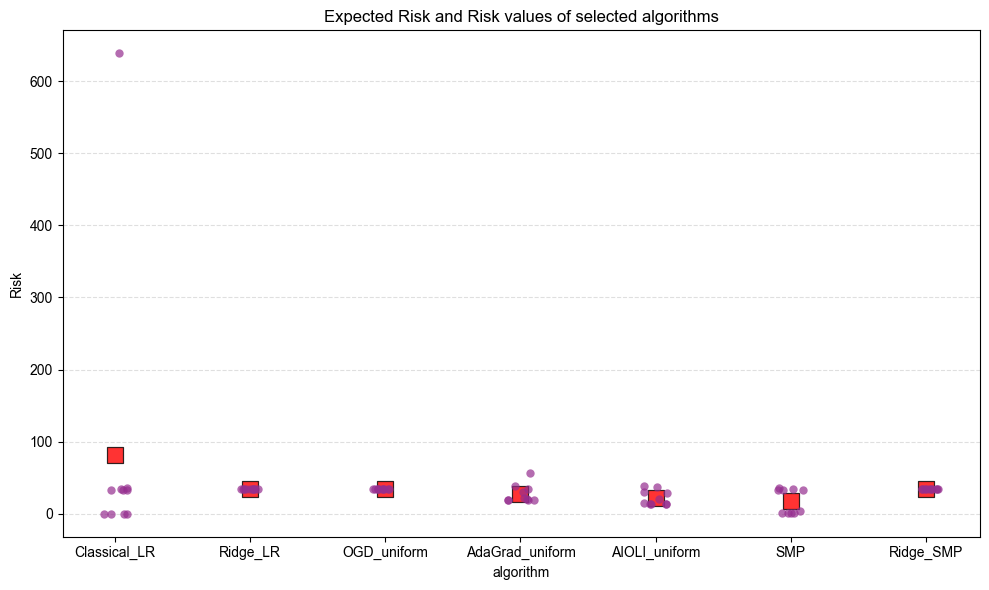

In [231]:
print_results(hazan_result, selected_algorithms = ["Classical_LR","SMP","AIOLI_uniform", "Ridge_LR","OGD_uniform","AdaGrad_uniform", "Ridge_SMP"], plot = True)

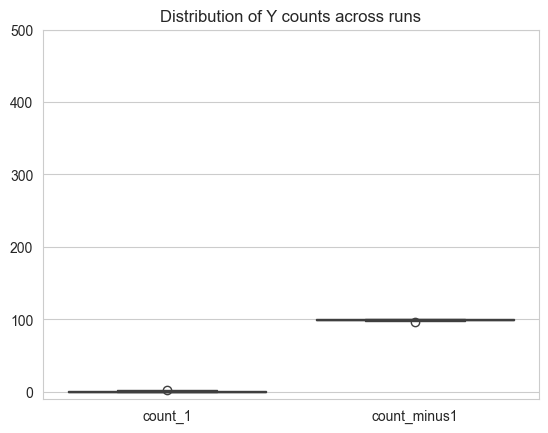

Train set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0  100.0  100.0     99     98  100.0     99  100.0  100.0     97      99
 1.0    NaN    NaN      1      2    NaN      1    NaN    NaN      3       1
Test set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0   50.0   50.0   50.0     49   50.0   50.0     49   50.0   50.0    50.0
 1.0    NaN    NaN    NaN      1    NaN    NaN      1    NaN    NaN     NaN


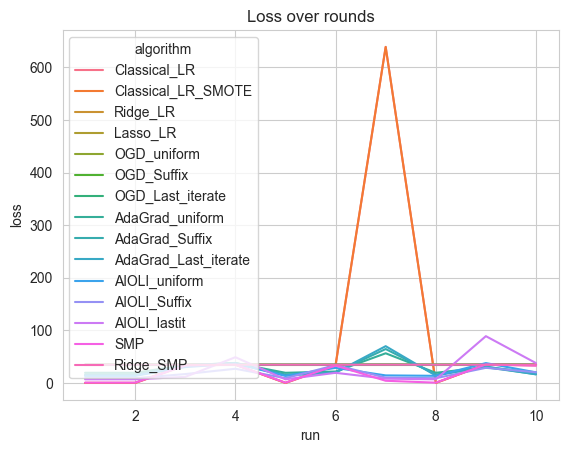

In [232]:
plot_results(hazan_result)

In [233]:
hazan_result["test_results"]

,run,algorithm,loss
0,1,Classical_LR,0.000128
1,1,Classical_LR_SMOTE,0.000128
2,1,Ridge_LR,34.410266
3,1,Lasso_LR,34.657359
4,1,OGD_uniform,34.598310
...,...,...,...
145,10,AIOLI_uniform,20.084898
146,10,AIOLI_Suffix,20.271376
147,10,AIOLI_lastit,37.698860
148,10,SMP,33.017581


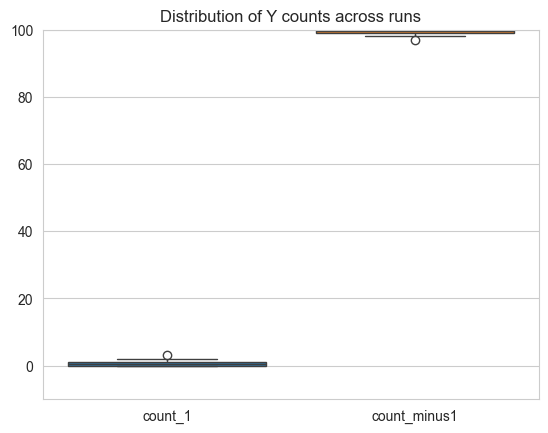

Train set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0  100.0  100.0     99     98  100.0     99  100.0  100.0     97      99
 1.0    NaN    NaN      1      2    NaN      1    NaN    NaN      3       1
Test set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0   50.0   50.0   50.0     49   50.0   50.0     49   50.0   50.0    50.0
 1.0    NaN    NaN    NaN      1    NaN    NaN      1    NaN    NaN     NaN


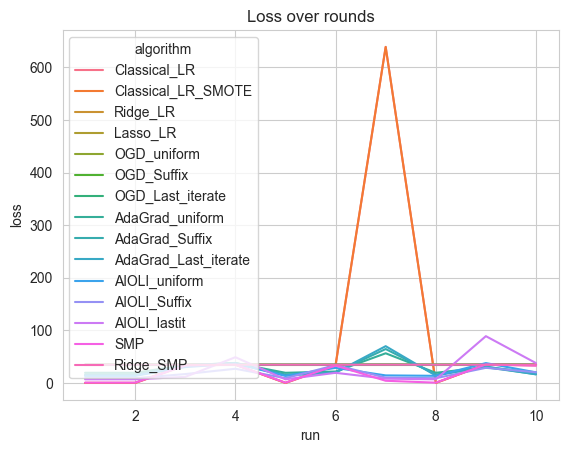

In [234]:
plot_results(hazan_result, n = 100)

In [235]:
hazan_Xminus1 = SimulationConfig(
    sim_setting = "hazan 1-dimensional",
    n = 100,
    runs = 10,
    X_hazan = -1
)

hazan_Xminus1_result = run_simulation(hazan_Xminus1)
print_results(hazan_Xminus1_result)

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204
Lasso LR was fit ma

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,15.225396,0.356539
AIOLI_lastit,20.804441,1.187065
AIOLI_uniform,19.611018,0.329390
AdaGrad_Last_iterate,24.987671,0.807232
AdaGrad_Suffix,25.240462,0.716683
AdaGrad_uniform,26.589293,0.558231
Classical_LR,80.835406,8.801082
Classical_LR_SMOTE,81.271760,8.795861
Lasso_LR,34.657359,0.000000


Total time: 0:01:08.856144


,Average_Loss,SE
algorithm,,
AIOLI_Suffix,15.225396,0.356539
AIOLI_lastit,20.804441,1.187065
AIOLI_uniform,19.611018,0.329390
AdaGrad_Last_iterate,24.987671,0.807232
AdaGrad_Suffix,25.240462,0.716683
AdaGrad_uniform,26.589293,0.558231
Classical_LR,80.835406,8.801082
Classical_LR_SMOTE,81.271760,8.795861
Lasso_LR,34.657359,0.000000


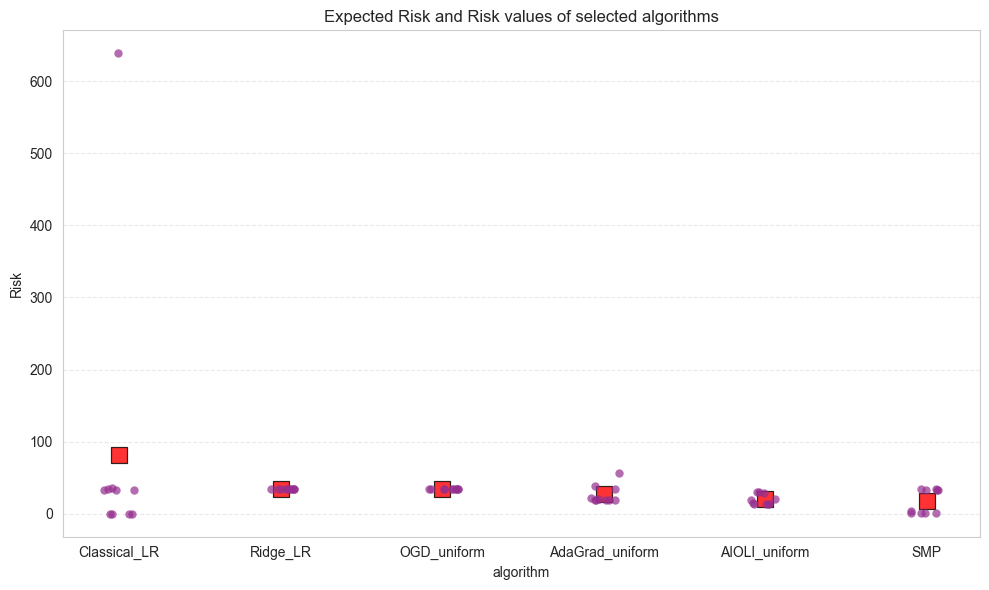

In [236]:
print_results(hazan_Xminus1_result, selected_algorithms = ["Classical_LR","SMP","AIOLI_uniform", "Ridge_LR","OGD_uniform","AdaGrad_uniform"], plot = True)

In [237]:
settings_results = {
    "Hazan": hazan_result,
    "Hazan_Xminus1": hazan_Xminus1_result
}

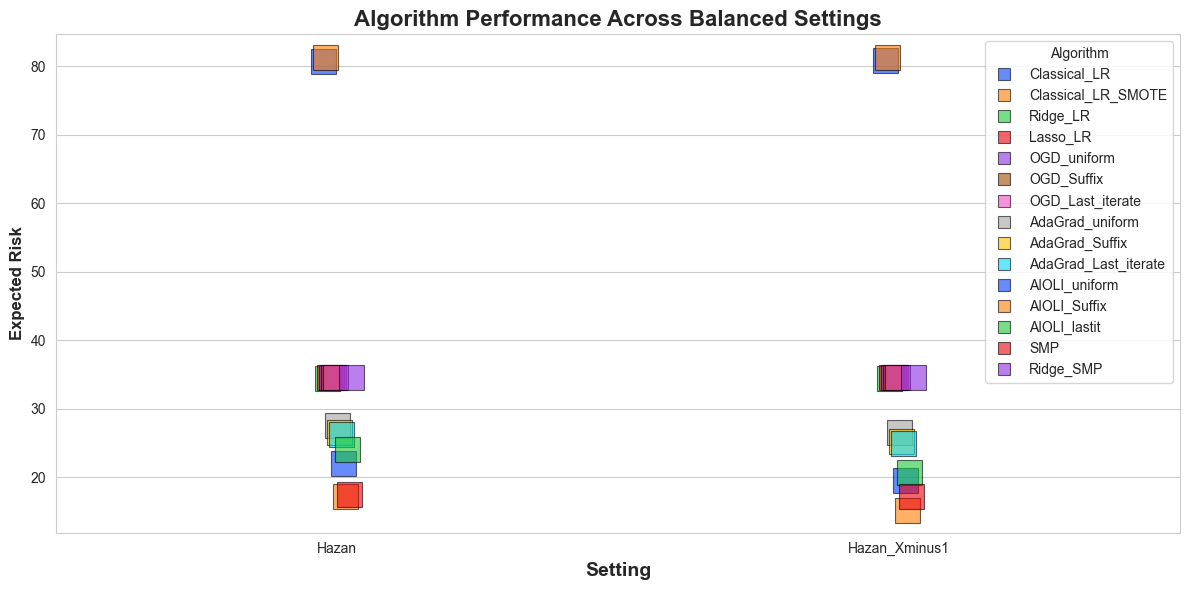

In [238]:
compare_settings(settings_results)

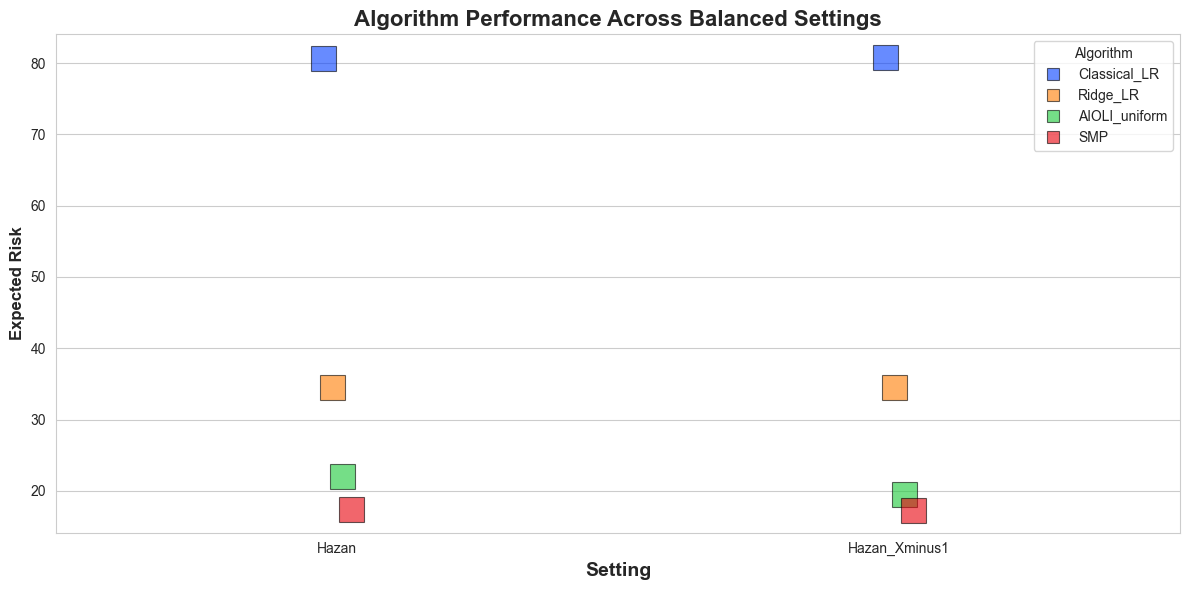

In [239]:

compare_settings(
    settings_results,
    selected_algorithms=["Classical_LR", "SMP", "AIOLI_uniform", "Ridge_LR"]
)

## Balanced

In [240]:
binomial = SimulationConfig(
    sim_setting = "binomial_x",
    n = 200,
    d = 1
)

binomial_result = run_simulation(binomial)
print_results(binomial_result)

200 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.545
Lasso LR was fit manually
Run 1 finished
200 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.596
Lasso LR was fit manually
Run 2 finished
200 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.542
Lasso LR was fit manually
Run 3 finished
200 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.534
Dataset is balanced
Lasso LR was fit manually
Run 4 finished
200 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.423
Lasso LR was fit manually
Run 5 finished
200 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.559
Dataset is ba

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,72.985220,0.273550
AIOLI_lastit,77.984316,0.601881
AIOLI_uniform,72.302858,0.501079
AdaGrad_Last_iterate,72.624055,0.286272
AdaGrad_Suffix,69.093579,0.063061
AdaGrad_uniform,68.084299,0.077879
Classical_LR,68.235295,0.051802
Classical_LR_SMOTE,71.991173,0.192302
Lasso_LR,68.357571,0.043537


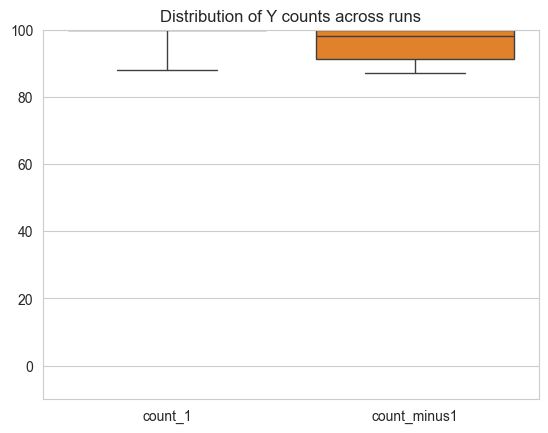

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     91     87     92    100     98    100     88    111    112      98
 1    109    113    108    100    102    100    112     89     88     102
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     42     45     50     49     61     43     38     57     52      57
 1     58     55     50     51     39     57     62     43     48      43


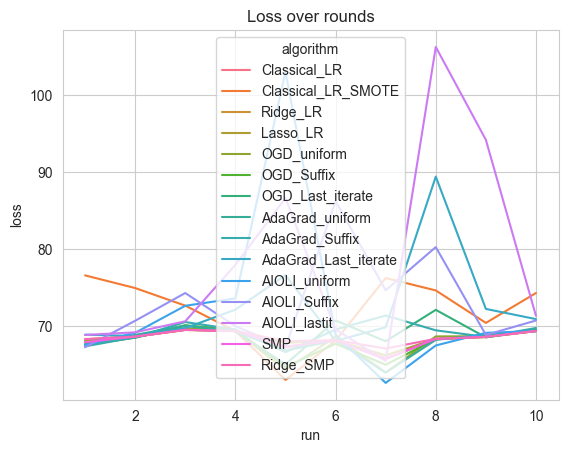

In [241]:
plot_results(binomial_result, n = 100)

In [242]:
# binomial_d3 = SimulationConfig(
#     sim_setting = "binomial_x",
#     n = 50,
#     runs = 10,
#     d = 3
# )
#
# binomial_d3_result = run_simulation(binomial_d3)
# print_results(binomial_d3_result)

In [243]:
well_specified = SimulationConfig(
    sim_setting = "well specified",
    d = 3
)

well_specified_result = run_simulation(well_specified)
print_results(well_specified_result)

500 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.508
Lasso LR was fit manually
Run 1 finished
500 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
Lasso LR was fit manually
Run 2 finished
500 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.506
Lasso LR was fit manually
Run 3 finished
500 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.503
Lasso LR was fit manually
Run 4 finished
500 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
Lasso LR was fit manually
Run 5 finished
500 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502
Lasso LR 

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,182.769362,0.579621
AIOLI_lastit,251.420708,4.672103
AIOLI_uniform,187.985338,1.215181
AdaGrad_Last_iterate,188.649199,1.070160
AdaGrad_Suffix,172.277862,0.124806
AdaGrad_uniform,171.329639,0.114819
Classical_LR,169.801571,0.106062
Classical_LR_SMOTE,183.532238,0.201216
Lasso_LR,170.097935,0.119631


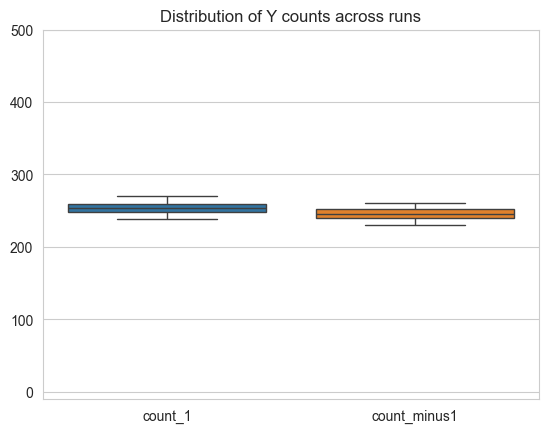

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    244    261    244    248    233    257    253    239    249     230
 1    256    239    256    252    267    243    247    261    251     270
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    110    132    121    123    124    136    115    126    119     123
 1    140    118    129    127    126    114    135    124    131     127


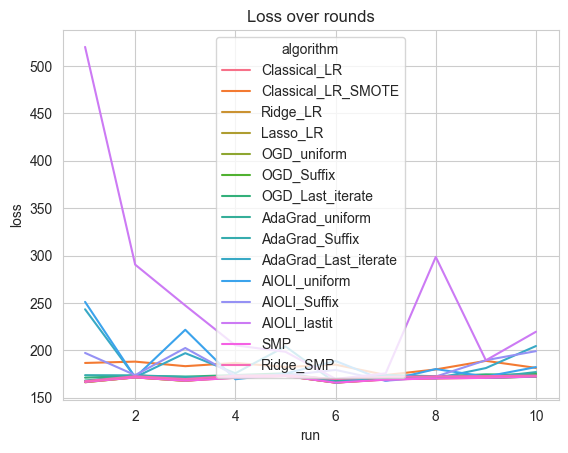

In [244]:
plot_results(well_specified_result)

In [245]:
# well_specified_largebetas = SimulationConfig(
#     sim_betas = [4.4,-0.4,-6.2],
#     sim_setting = "well specified",
#     d = 3,
#     n = 100,
#     runs = 5
# )
#
# well_specified_largebetas_result = run_simulation(well_specified_largebetas)
# print_results(well_specified_largebetas_result)

In [246]:
# plot_results(well_specified_largebetas_result, n = 100)

In [247]:
high_dimensional = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25,
    runs = 20
)

In [248]:

high_dimensional_result = run_simulation(high_dimensional)
print_results(high_dimensional_result)

20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.533
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.526
Lasso LR was fit manually
Run 2 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.63
Lasso LR was fit manually
Run 3 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.553
Lasso LR was fit manually
Run 4 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.552
Dataset is balanced
Lasso LR was fit manually
Run 5 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an av

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,6.486992,4.132481e-02
AIOLI_lastit,6.243955,5.515109e-02
AIOLI_uniform,6.499204,3.450380e-02
AdaGrad_Last_iterate,178.510030,6.754748e+00
AdaGrad_Suffix,113.910978,4.421297e+00
AdaGrad_uniform,130.423381,6.053112e+00
Classical_LR,76.946138,4.502393e+00
Classical_LR_SMOTE,91.377065,5.016565e+00
Lasso_LR,6.785582,2.555279e-02


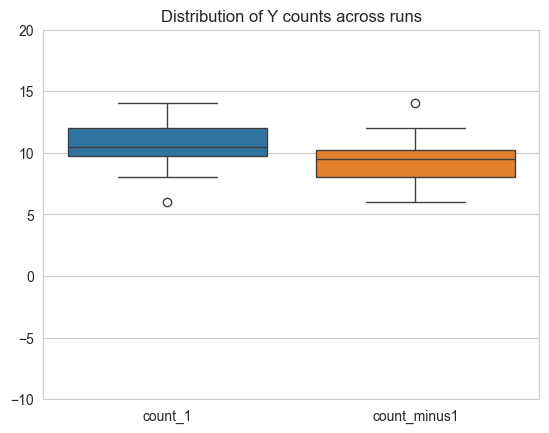

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
-1      8      9      8     12     10      9     11     14     10      12   
 1     12     11     12      8     10     11      9      6     10       8   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
-1       8       6      10      11      10       8      10       9       9   
 1      12      14      10       9      10      12      10      11      11   

    run_20  
-1       8  
 1      12  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
-1      5      6      2      4      5      7      5      4      5       5   
 1      5      4      8      6      5      3      5      6      5       5   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
-1       2       6       5       6       5       3       4       5       4   
 1       8       4       5       4       5       7       6       5       6   

    run_

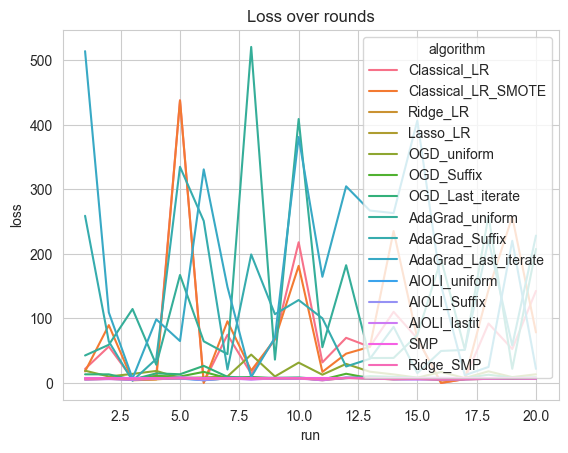

In [249]:
plot_results(high_dimensional_result, n = 20)

In [250]:
high_dimensionality = SimulationConfig(
    sim_setting = "high dimensional",
    runs = 20,
    n = 50,
    d = 25
)

high_dimensionality_result = run_simulation(high_dimensionality)
print_results(high_dimensionality_result)

50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.514
Lasso LR was fit manually
Run 1 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.441
Lasso LR was fit manually
Run 2 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.535
Lasso LR was fit manually
Run 3 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.582
Lasso LR was fit manually
Run 4 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.548
Lasso LR was fit manually
Run 5 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.4

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,21.860193,0.804356
AIOLI_lastit,27.899130,2.092621
AIOLI_uniform,17.749780,0.452732
AdaGrad_Last_iterate,274.766287,8.338211
AdaGrad_Suffix,185.169222,4.693288
AdaGrad_uniform,140.689381,6.072076
Classical_LR,676.786587,48.205226
Classical_LR_SMOTE,1140.334977,80.967940
Lasso_LR,14.719613,0.118686


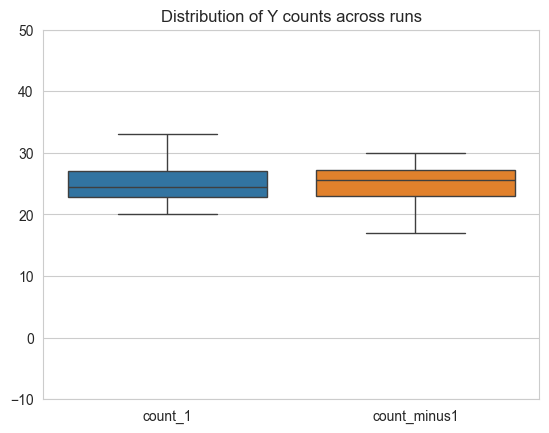

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
-1     23     26     26     17     23     26     29     28     28      23   
 1     27     24     24     33     27     24     21     22     22      27   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
-1      26      24      29      22      23      22      27      30      25   
 1      24      26      21      28      27      28      23      20      25   

    run_20  
-1      21  
 1      29  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
-1     10     14      8     14     13     15     13     15     13      14   
 1     15     11     17     11     12     10     12     10     12      11   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
-1       8      10      11      14      12       8      11      11      11   
 1      17      15      14      11      13      17      14      14      14   

    run_

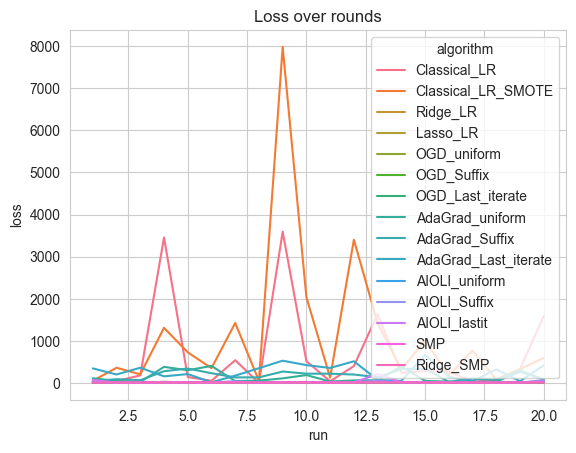

In [251]:
plot_results(high_dimensionality_result, n = 50)

In [252]:
# sinusoidal = SimulationConfig(
#     sim_setting = "sinusoidal",
#     n = 100,
#     d = 3
# )
#
# sinusoidal_result = run_simulation(sinusoidal)
# print_results(sinusoidal_result)

In [253]:
# plot_results(sinusoidal_result)

In [254]:
quadratic = SimulationConfig(
    sim_setting = "quadratic",
    d = 3
)

quadratic_result = run_simulation(quadratic)
print_results(quadratic_result)

500 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.053
Lasso LR was fit manually
Run 1 finished
500 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.053
Lasso LR was fit manually
Run 2 finished
500 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.054
Lasso LR was fit manually
Run 3 finished
500 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.048
Lasso LR was fit manually
Run 4 finished
500 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.045
Lasso LR was fit manually
Run 5 finished
500 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.049
Lasso LR was fit manually
Run 6 finishe

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,196.637889,1.316638
AIOLI_lastit,245.660171,4.144869
AIOLI_uniform,283.974119,5.191452
AdaGrad_Last_iterate,158.314261,0.834190
AdaGrad_Suffix,146.967866,0.466922
AdaGrad_uniform,146.348895,0.478613
Classical_LR,144.473220,0.484363
Classical_LR_SMOTE,154.133780,0.594691
Lasso_LR,144.838364,0.486350


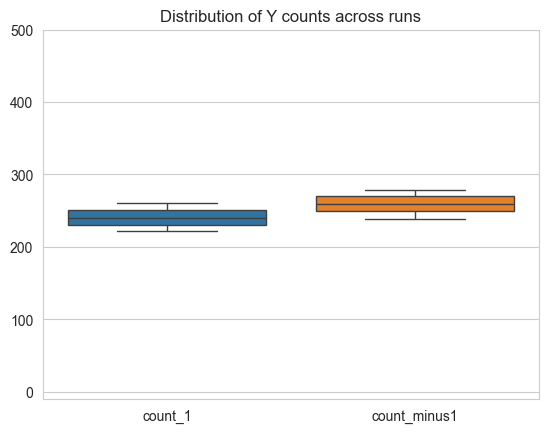

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    261    260    259    255    247    274    278    273    239     241
 1    239    240    241    245    253    226    222    227    261     259
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    126    145    127    131    133    144    116    132    130     136
 1    124    105    123    119    117    106    134    118    120     114


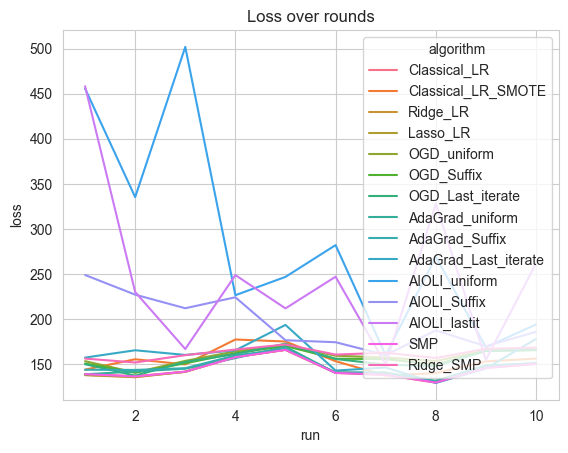

In [255]:
plot_results(quadratic_result)

In [256]:
settings_results1 = {
    # "Well specified": well_specified_result,
    # "High Dimensional": high_dimensional_result,
    "High Dimensionality": high_dimensionality_result,
    # "Quadratic": quadratic_result,
    # "Binomial X": binomial_result
}
settings_results = {
    "Well specified": well_specified_result,
    "High Dimensional": high_dimensional_result,
    # "High Dimensionality": high_dimensionality_result,
    "Quadratic": quadratic_result,
    "Binomial X": binomial_result
}

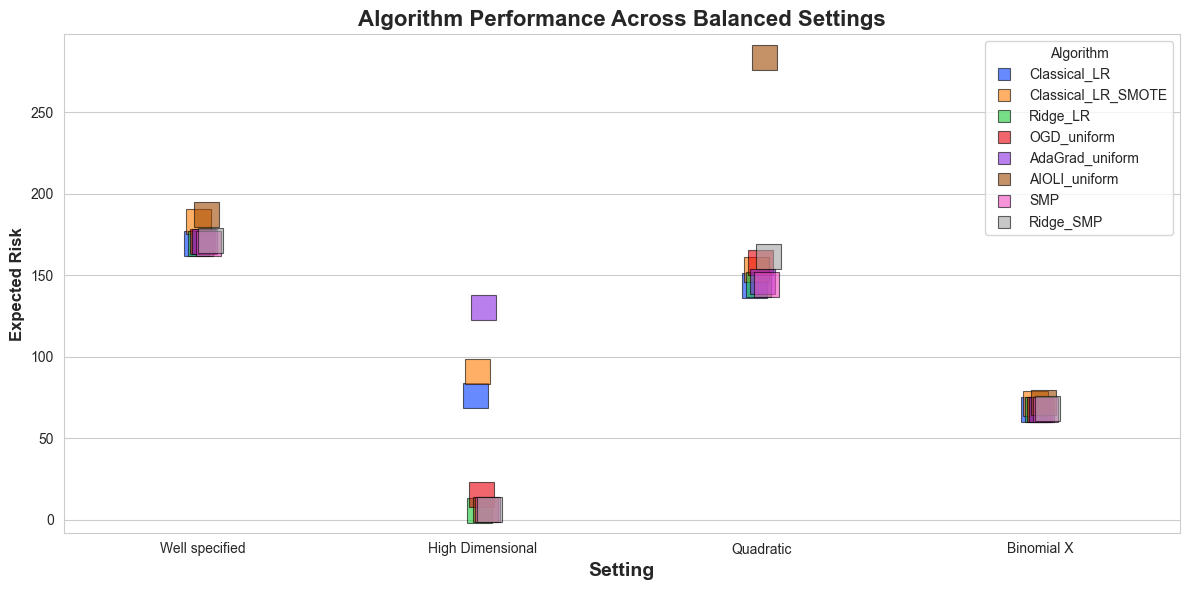

In [257]:
compare_settings(
    settings_results, selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"]
)

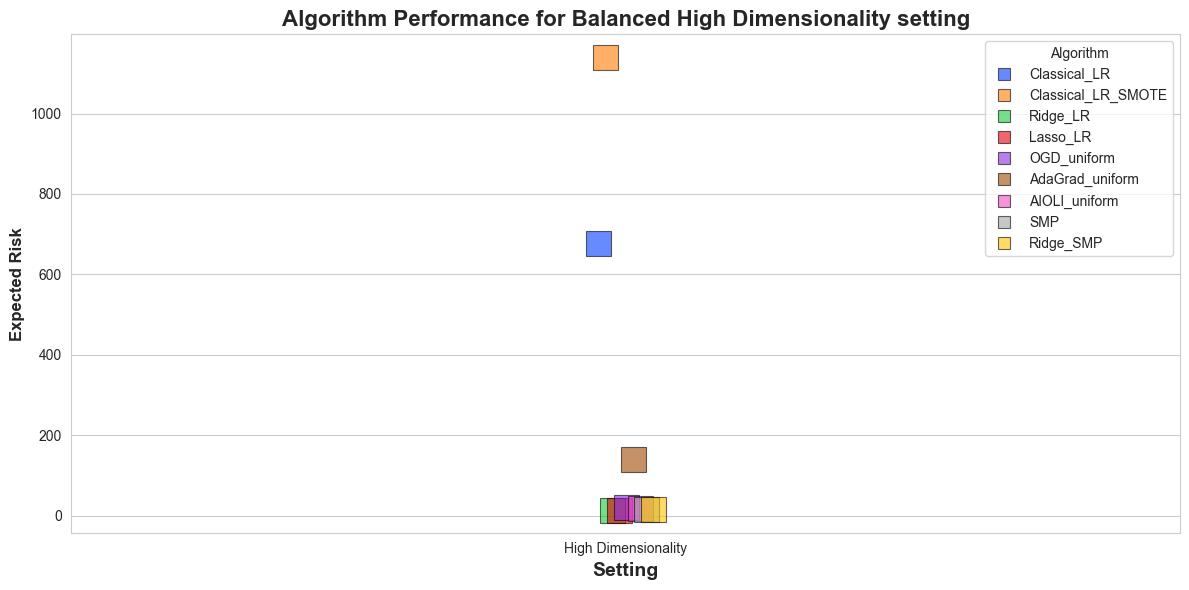

In [258]:
compare_settings(
    settings_results1,
    title = "Algorithm Performance for Balanced High Dimensionality setting", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"]
)

In [259]:

settings_results_HD = {
    # "Well specified": well_specified_result,
    "High Dimensional": high_dimensional_result,
    "High Dimensionality": high_dimensionality_result,
    # "Quadratic": quadratic_result,
    # "Binomial X": binomial_result
}

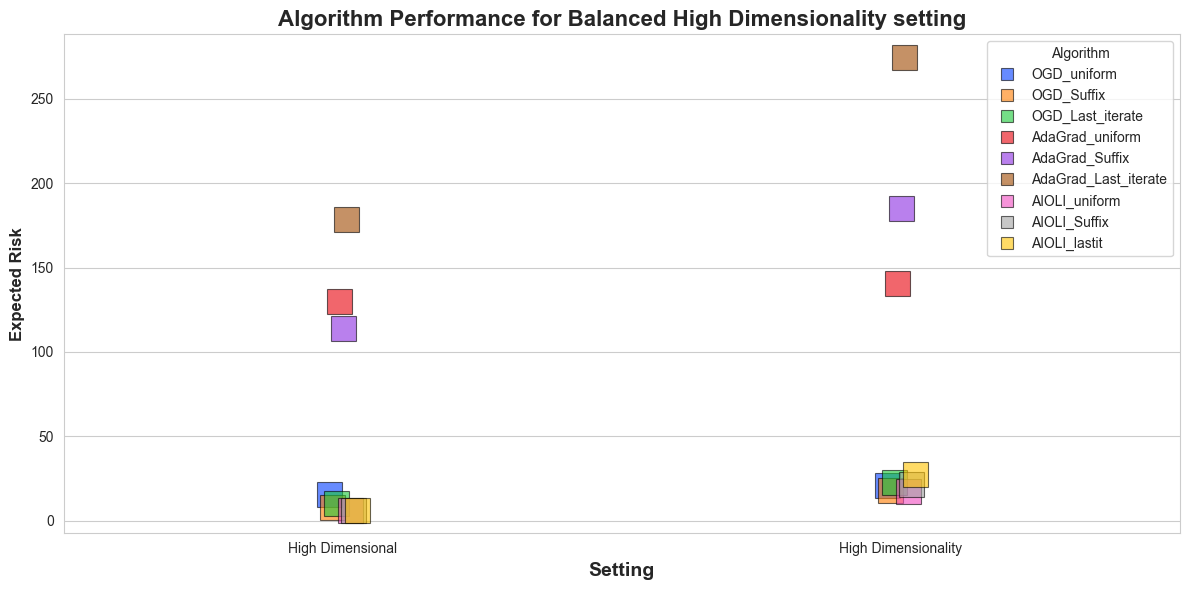

In [260]:
compare_settings(
    settings_results_HD,
    title = "Algorithm Performance for Balanced High Dimensionality setting", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"]
)

In [261]:
highly_correlated_x = SimulationConfig(
    sim_setting = "highly correlated x",
    n = 100,
    d = 3
)

highly_correlated_x_result = run_simulation(highly_correlated_x)
print_results(highly_correlated_x_result)

100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.547
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.237
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.532
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.637
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an ave

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,46.495702,0.544701
AIOLI_lastit,46.392128,1.071888
AIOLI_uniform,47.561354,0.498898
AdaGrad_Last_iterate,64.160473,1.404626
AdaGrad_Suffix,36.308228,0.201634
AdaGrad_uniform,37.839736,0.185109
Classical_LR,32.996586,0.146724
Classical_LR_SMOTE,35.445022,0.180176
Lasso_LR,33.011967,0.139714


In [262]:
alternating = SimulationConfig(
    sim_setting = "alternating",
    n = 100,
    d = 3,
    runs = 4
)

alternating_result = run_simulation(alternating)
print_results(alternating_result)

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.478
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.468
Dataset is balanced
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.453
Dataset is balanced
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.442
Dataset is balanced
Lasso LR was fit manually
Run 4 finished
Total time: 0:02:30.811790


,Average_Loss,SE
algorithm,,
AIOLI_Suffix,39.945203,0.270906
AIOLI_lastit,38.595993,0.145591
AIOLI_uniform,44.901781,0.687455
AdaGrad_Last_iterate,40.808966,0.091852
AdaGrad_Suffix,37.229554,0.155676
AdaGrad_uniform,37.868472,0.188630
Classical_LR,35.369201,0.041825
Classical_LR_SMOTE,35.369201,0.041825
Lasso_LR,34.738284,0.007238


## Unbalanced

### Experiments

In [263]:
1 - (0.002 +0.002)

0.996

In [264]:
binomial_unbalanced = SimulationConfig(
    sim_setting = "binomial_x",
    n = 100,
    d = 1,
    sim_balanced= False
)

binomial_unbalanced_result = run_simulation(binomial_unbalanced)
print_results(binomial_unbalanced_result)

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.994
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.99
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.993
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.994
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the binomial_x unbalanced 

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,16.800426,1.678196
AIOLI_lastit,16.379249,1.661866
AIOLI_uniform,17.030120,1.633065
AdaGrad_Last_iterate,3.173782,0.352336
AdaGrad_Suffix,3.095453,0.350342
AdaGrad_uniform,3.245952,0.351895
Classical_LR,3.037080,0.315852
Classical_LR_SMOTE,3.403349,0.312598
Lasso_LR,1.439192,0.091816


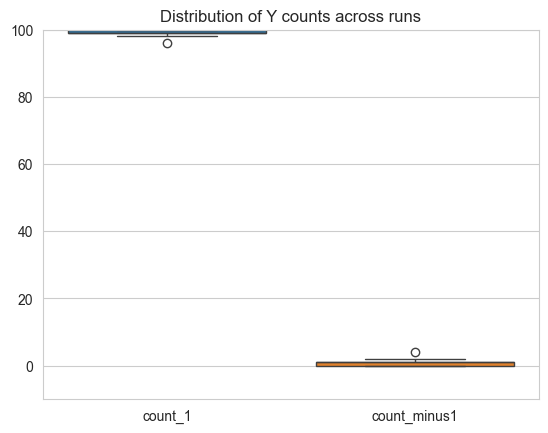

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    NaN      1    NaN      1    NaN      2    NaN      4      1       1
 1  100.0     99  100.0     99  100.0     98  100.0     96     99      99
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    NaN    NaN      1    NaN    NaN      1    NaN    NaN    NaN     NaN
 1   50.0   50.0     49   50.0   50.0     49   50.0   50.0   50.0    50.0


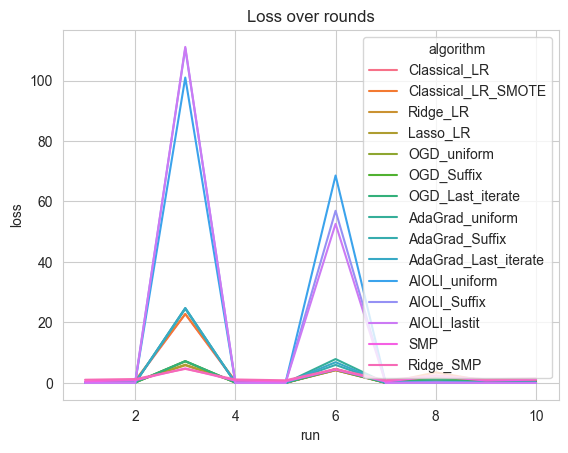

In [265]:
plot_results(binomial_unbalanced_result, n = 100)

In [266]:
well_specified_unbalanced = SimulationConfig(
    sim_setting = "well specified",
    sim_balanced= False
)

well_specified_unbalanced_result = run_simulation(well_specified_unbalanced)
print_results(well_specified_unbalanced_result)

500 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.992
Lasso LR was fit manually
Run 1 finished
500 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.995
Lasso LR was fit manually
Run 2 finished
500 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.995
Lasso LR was fit manually
Run 3 finished
500 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.997
Lasso LR was fit manually
Run 4 finished
500 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.997
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 5 finished
500

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,45.653456,2.650285
AIOLI_lastit,42.423145,3.748691
AIOLI_uniform,44.055361,2.595960
AdaGrad_Last_iterate,7.017630,0.327355
AdaGrad_Suffix,8.357263,0.405042
AdaGrad_uniform,9.742094,0.474617
Classical_LR,6.666866,0.299931
Classical_LR_SMOTE,6.880969,0.279756
Lasso_LR,6.756063,0.264955


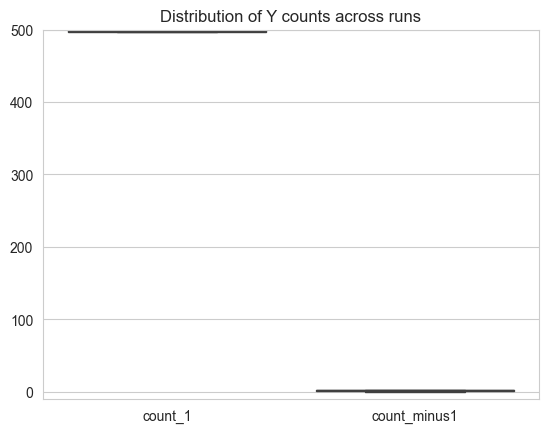

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1      2      3      3      1    NaN      1      1      3      3       3
 1    498    497    497    499  500.0    499    499    497    497     497
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1      2    NaN      2    NaN    NaN      3    NaN      3      1       1
 1    248  250.0    248  250.0  250.0    247  250.0    247    249     249


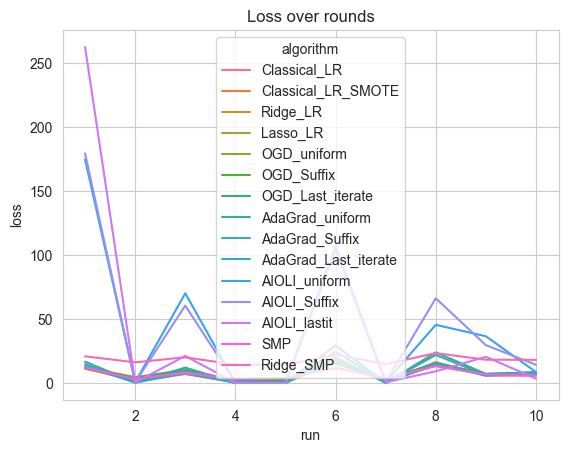

In [267]:
plot_results(well_specified_unbalanced_result)

In [268]:
high_dimensional_unbalanced = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25,
    runs = 20,
    sim_balanced= False
)

high_dimensional_unbalanced_result = run_simulation(high_dimensional_unbalanced)
print_results(high_dimensional_unbalanced_result)


20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.821
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.835
Lasso LR was fit manually
Run 2 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.846
Lasso LR was fit manually
Run 3 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.764
Lasso LR was fit manually
Run 4 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.827
Lasso LR was fit manually
Run 5 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,4.633267,8.903628e-02
AIOLI_lastit,4.885852,7.262234e-02
AIOLI_uniform,4.647174,7.306362e-02
AdaGrad_Last_iterate,102.935610,8.292447e+00
AdaGrad_Suffix,73.028031,2.804018e+00
AdaGrad_uniform,120.524433,4.179136e+00
Classical_LR,46.680858,2.286884e+00
Classical_LR_SMOTE,33.925305,1.299250e+00
Lasso_LR,4.921841,1.052791e-01


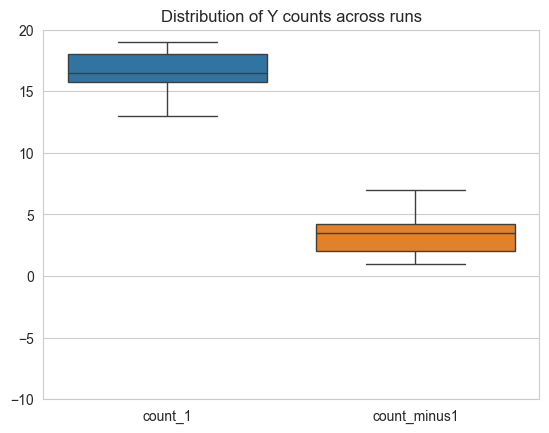

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
 1     17     15     15     15     16     18     16     13     19      17   
-1      3      5      5      5      4      2      4      7      1       3   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
 1      18      19      18      18      16      18      14      16      16   
-1       2       1       2       2       4       2       6       4       4   

    run_20  
 1      17  
-1       3  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
-1      2    NaN      2      1      3      5      1      3      1       1   
 1      8   10.0      8      9      7      5      9      7      9       9   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
-1     NaN       3       1       3       2       2       1       1     NaN   
 1    10.0       7       9       7       8       8       9       9    10.0   

    run_

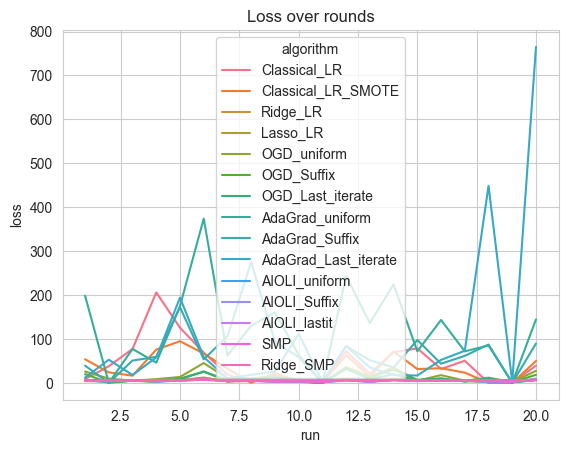

In [269]:
plot_results(high_dimensional_unbalanced_result, n = 20)

In [270]:
high_dimensionality_unbalanced = SimulationConfig(
    sim_setting = "high dimensional",
    runs = 20,
    n = 50,
    d = 25,
    sim_balanced = False
)

high_dimensionality_unbalanced_result = run_simulation(high_dimensionality_unbalanced)
print_results(high_dimensionality_unbalanced_result)


50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.784
Lasso LR was fit manually
Run 1 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.788
Lasso LR was fit manually
Run 2 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.789
Lasso LR was fit manually
Run 3 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.837
Lasso LR was fit manually
Run 4 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.851
Lasso LR was fit manually
Run 5 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,24.172731,1.354855
AIOLI_lastit,36.775355,2.069852
AIOLI_uniform,18.425877,0.838567
AdaGrad_Last_iterate,202.032729,12.549535
AdaGrad_Suffix,97.042638,4.327530
AdaGrad_uniform,141.218147,4.707243
Classical_LR,288.041657,9.907980
Classical_LR_SMOTE,253.844579,9.068596
Lasso_LR,10.542342,0.088183


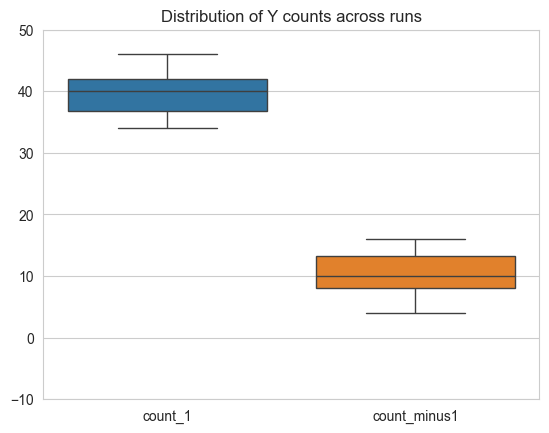

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
 1     38     38     39     46     42     40     44     34     35      45   
-1     12     12     11      4      8     10      6     16     15       5   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
 1      36      40      43      41      37      41      35      34      42   
-1      14      10       7       9      13       9      15      16       8   

    run_20  
 1      41  
-1       9  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
 1     22     21     20     20     19     18     22     18     23      22   
-1      3      4      5      5      6      7      3      7      2       3   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
 1      24      21      23      21      21      21      20      23      22   
-1       1       4       2       4       4       4       5       2       3   

    run_

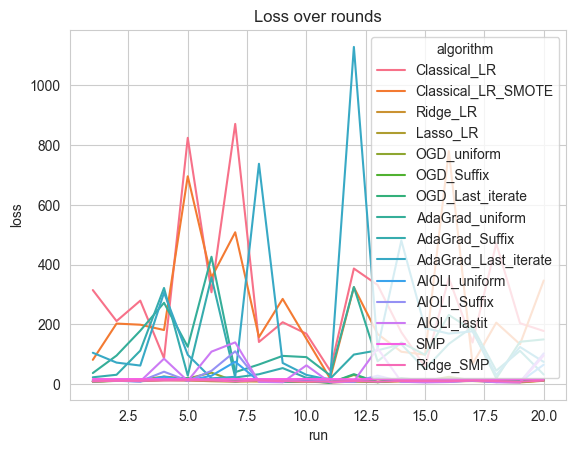

In [271]:
plot_results(high_dimensionality_unbalanced_result, n =50)

In [272]:
# sinusoidal_unbalanced = SimulationConfig(
#     sim_setting = "sinusoidal",
#     n = 100,
#     d = 3,
#     sim_balanced=False
# )
#
# sinusoidal_unbalanced_result = run_simulation(sinusoidal_unbalanced)
# print_results(sinusoidal_unbalanced_result)

In [273]:
# plot_results(sinusoidal_unbalanced_result, n = 100)

In [274]:
quadratic_unbalanced = SimulationConfig(
    sim_setting = "quadratic",
    d = 3,
    sim_balanced= False
)

quadratic_unbalanced_result = run_simulation(quadratic_unbalanced)
print_results(quadratic_unbalanced_result)

500 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.084
Lasso LR was fit manually
Run 1 finished
500 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.08
Lasso LR was fit manually
Run 2 finished
500 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.076
Lasso LR was fit manually
Run 3 finished
500 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.068
Lasso LR was fit manually
Run 4 finished
500 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.068
Lasso LR was fit manually
Run 5 finished
500 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.075
Lasso LR was fit manually
Ru

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,110.618552,2.694358
AIOLI_lastit,83.443952,3.293875
AIOLI_uniform,118.114677,2.752152
AdaGrad_Last_iterate,16.893272,0.367261
AdaGrad_Suffix,16.665292,0.335795
AdaGrad_uniform,18.515885,0.387574
Classical_LR,14.174999,0.266339
Classical_LR_SMOTE,15.459184,0.265784
Lasso_LR,14.450562,0.269097


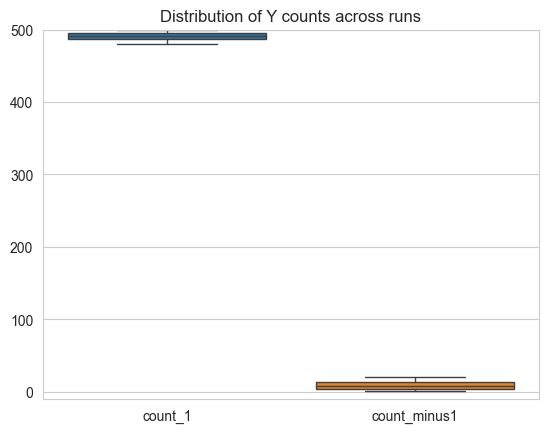

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
 1    480    491    490    498    499    486    496    486    492     494
-1     20      9     10      2      1     14      4     14      8       6
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
 1    247    247    247    248    249    243    249    247    244     245
-1      3      3      3      2      1      7      1      3      6       5


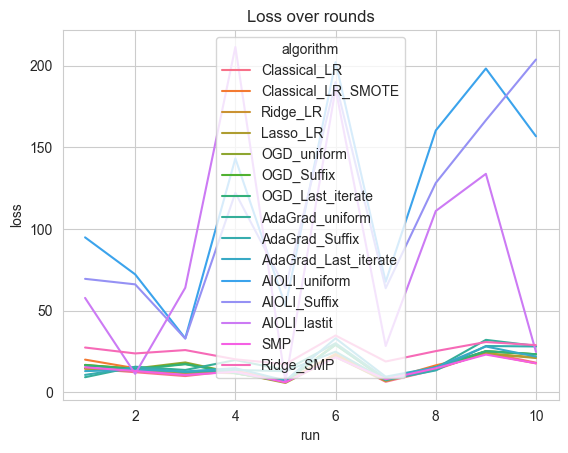

In [275]:
plot_results(quadratic_unbalanced_result)

In [276]:
settings_unbalanced_results = {
    "Well specified": well_specified_unbalanced_result,
    "High Dimensional": high_dimensional_unbalanced_result,
    # "High Dimensionality": high_dimensionality_unbalanced_result,
    "Quadratic": quadratic_unbalanced_result,
    "Binomial X": binomial_unbalanced_result
}

settings_unbalanced_results1 = {
    # "Well specified": well_specified_unbalanced_result,
    # "High Dimensional": high_dimensional_unbalanced_result,
    "High Dimensionality": high_dimensionality_unbalanced_result,
    # "Quadratic": quadratic_unbalanced_result,
    # "Binomial X": binomial_unbalanced_result
}

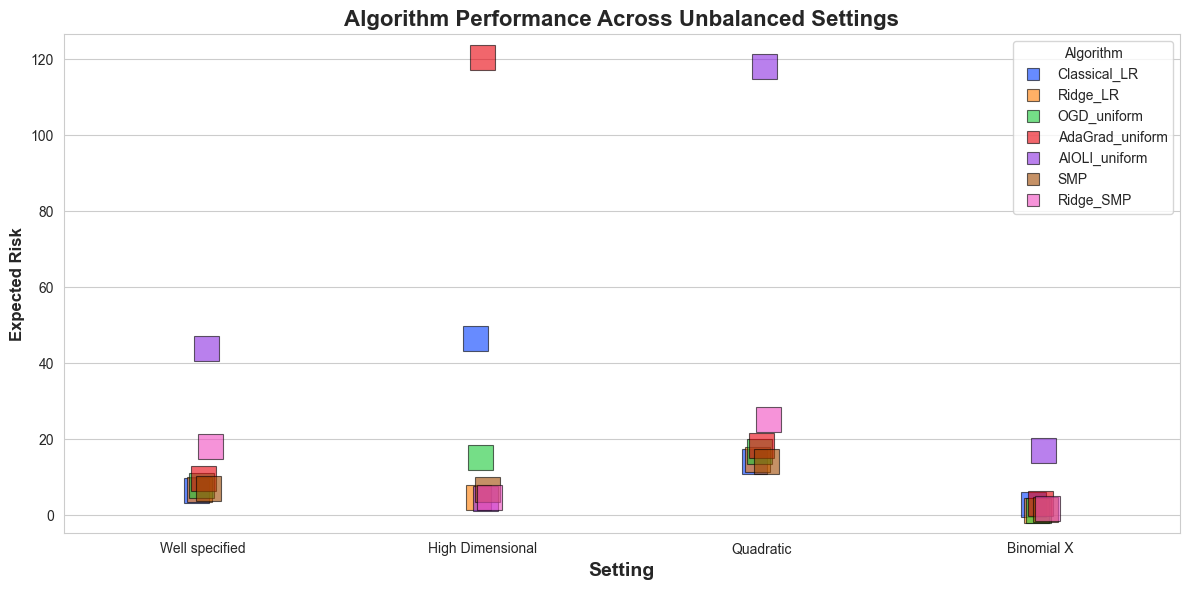

In [277]:
compare_settings(
    settings_unbalanced_results,
    title = "Algorithm Performance Across Unbalanced Settings", selected_algorithms= [ "Classical_LR", "Ridge_LR","OGD_uniform","AIOLI_uniform","SMP","Ridge_SMP", "AdaGrad_uniform"]
)

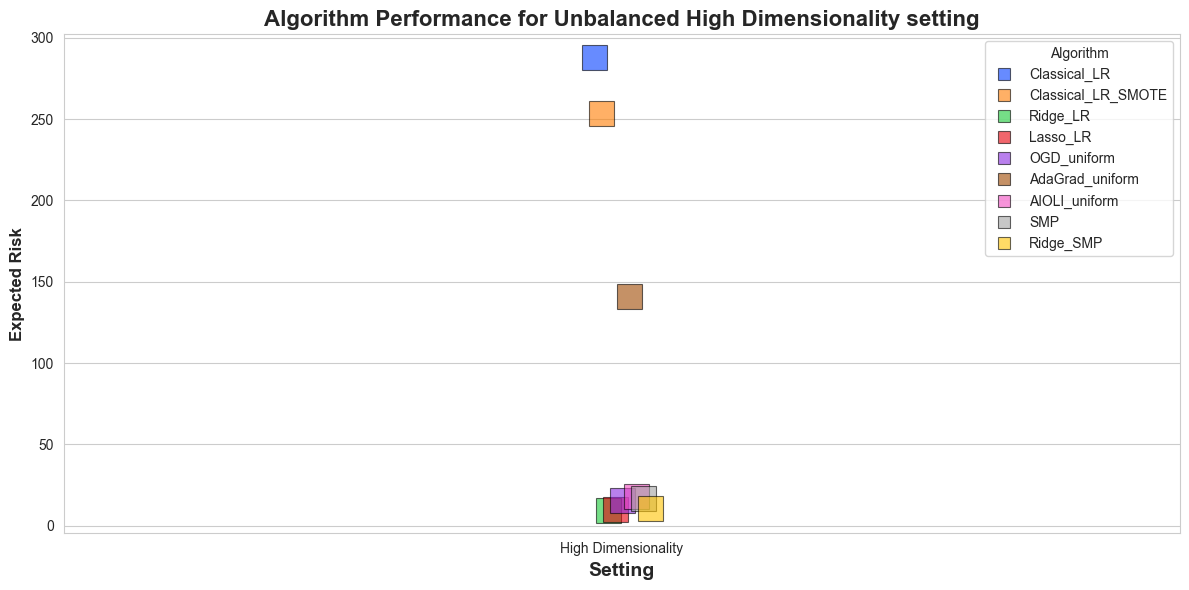

In [278]:
compare_settings(
    settings_unbalanced_results1,
    title = "Algorithm Performance for Unbalanced High Dimensionality setting", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"]
)

## Changing n

In [279]:
hazan_changing_n = simulations_changing_n([20,200,300,500], hazan, filename = "hazan_changing_n")

Running simulations for n = 20

20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.017640846227712365
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.017640846227712365
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.017640846227712365
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
20 (training) 

In [280]:
# hazan_changing_n[1]

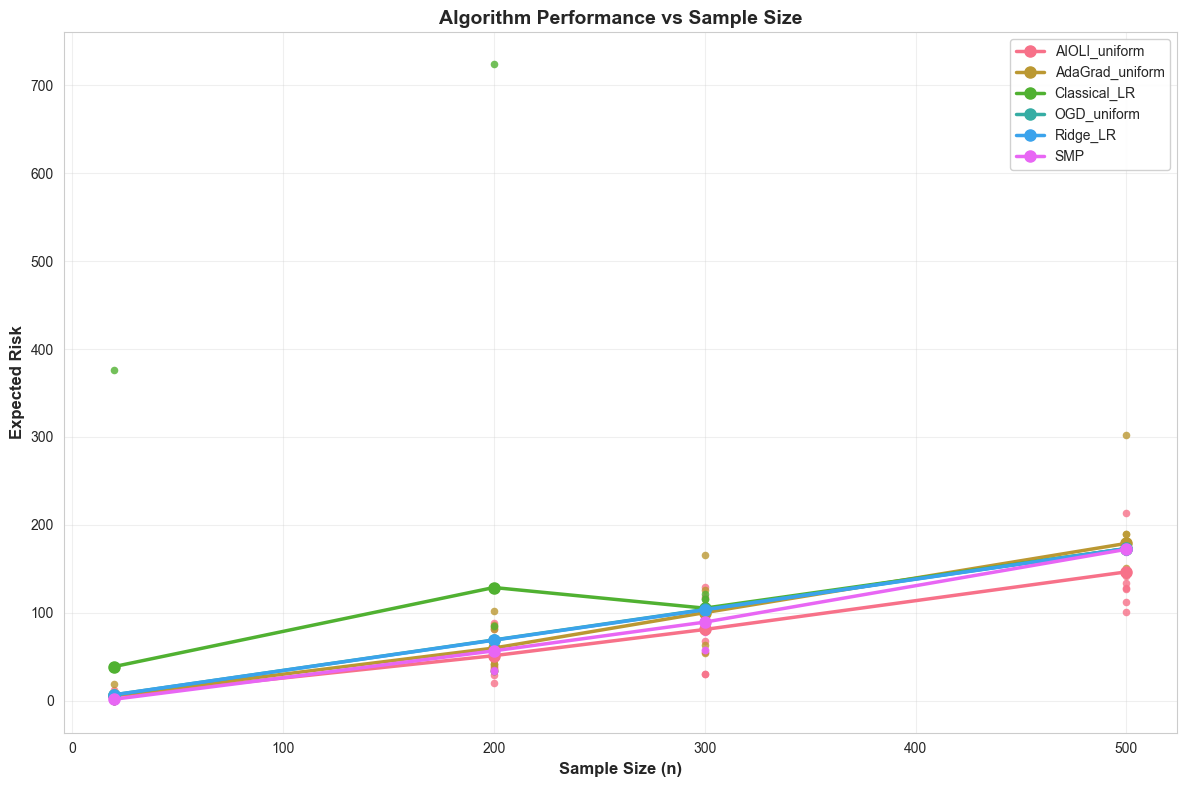

In [281]:
plot_simulation_results(summary_df= hazan_changing_n[0],algorithms = ["AIOLI_uniform","Classical_LR", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform"] ,raw_data= hazan_changing_n[1])

In [282]:
high_dimensional_changing_n = simulations_changing_n([10,50,100,150], high_dimensional, filename = "high_dimensional_changing_n")


Running simulations for n = 10

10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.525
Lasso LR was fit manually
Run 1 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.541
Lasso LR was fit manually
Run 2 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.705
Lasso LR was fit manually
Run 3 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.547
Lasso LR was fit manually
Run 4 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.505
Lasso LR was fit manually
Run 5 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s

In [283]:
# high_dimensional_changing_n

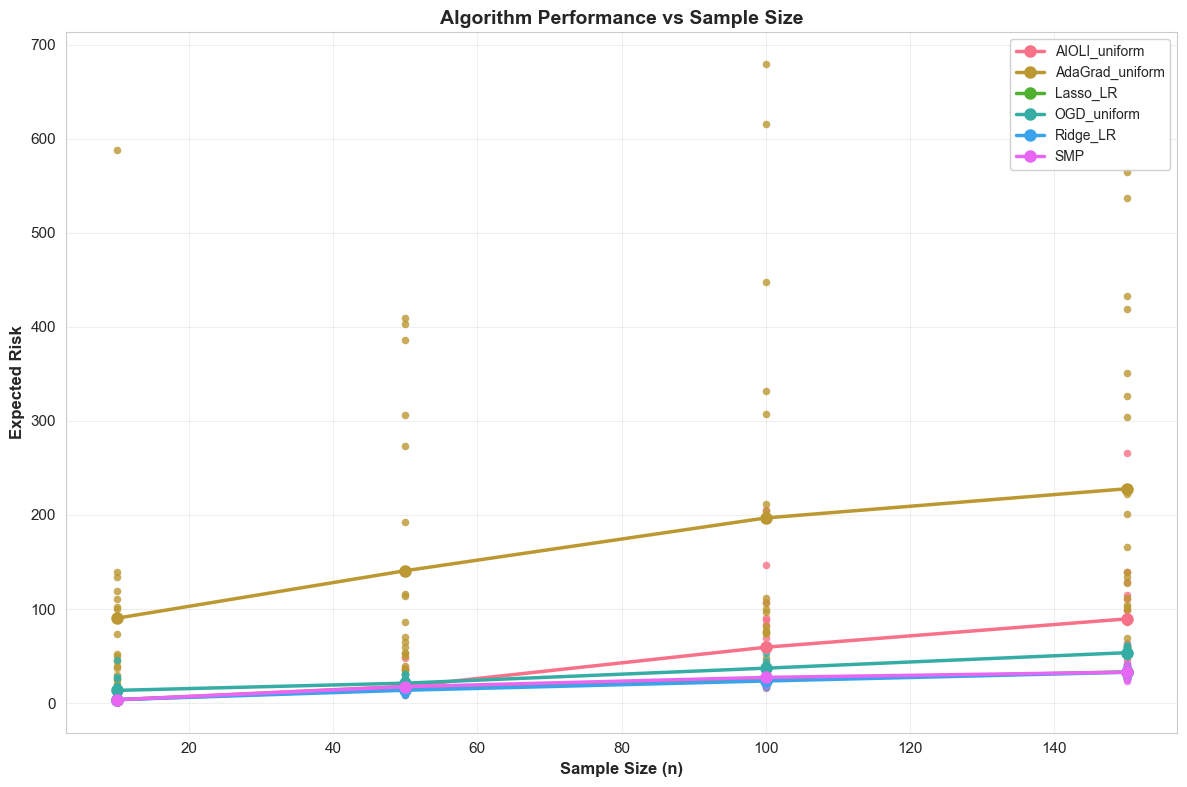

In [284]:
plot_simulation_results(summary_df= high_dimensional_changing_n[0],algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR","AdaGrad_uniform","OGD_uniform"] ,raw_data= high_dimensional_changing_n[1])

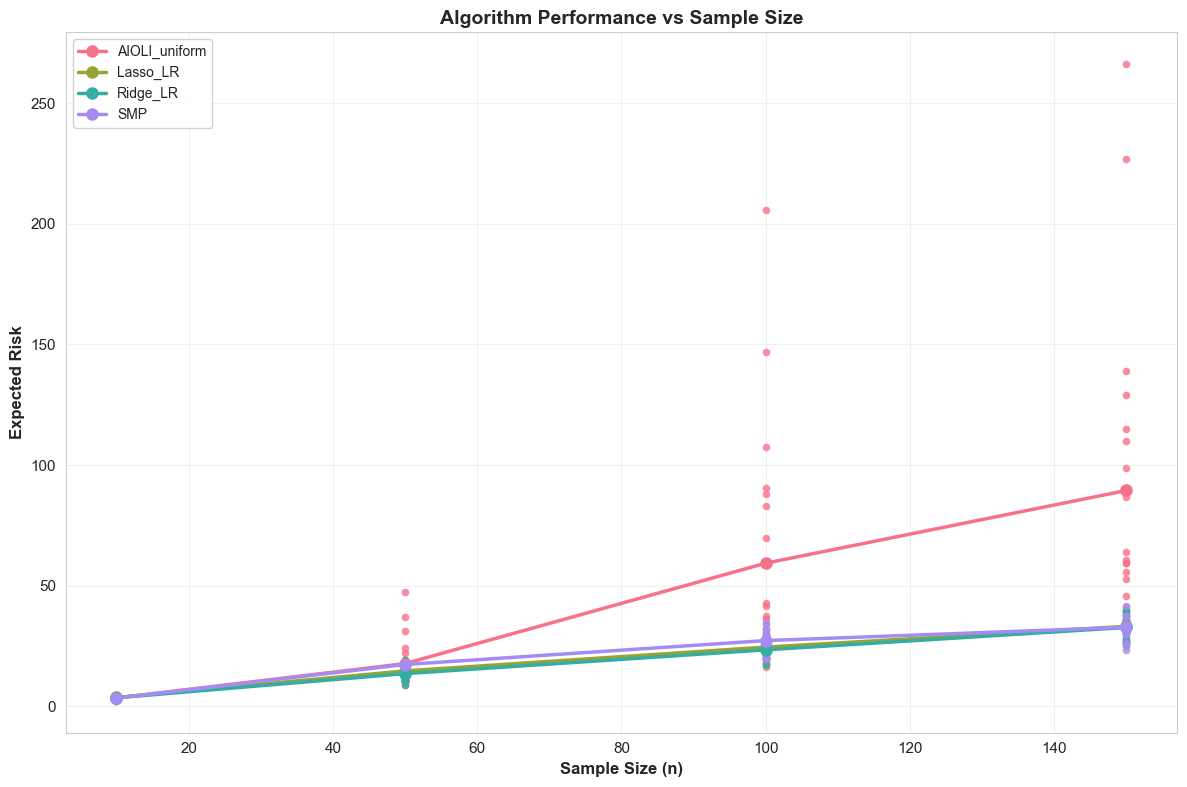

In [285]:
plot_simulation_results(summary_df= high_dimensional_changing_n[0],algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR"] ,raw_data= high_dimensional_changing_n[1])

In [286]:
high_dimensional_changing_n[0]

,n,algorithm,avg_loss,std_loss,num_runs
0,10,AIOLI_Suffix,3.519703,0.468737,20
1,10,AIOLI_lastit,3.351182,0.410963,20
2,10,AIOLI_uniform,3.508374,0.412631,20
3,10,AdaGrad_Last_iterate,94.784072,95.727238,20
4,10,AdaGrad_Suffix,126.917508,135.155613,20
5,10,AdaGrad_uniform,90.151286,124.376818,20
6,10,Classical_LR,20.415275,14.370835,20
7,10,Classical_LR_SMOTE,14.768301,10.802986,20
8,10,Lasso_LR,3.704226,0.630606,20
9,10,OGD_Last_iterate,8.849074,7.264462,20


In [287]:
well_specified_changing_n = simulations_changing_n([10,20,30,50,100], well_specified, filename = "well_specified_changing_n")

Running simulations for n = 10

10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.503
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498
Dataset is balanced
Lasso LR was fit manually
Run 2 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
Lasso LR was fit manually
Run 3 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511
Lasso LR was fit manually
Run 4 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.51
Lasso LR was fit manually
Run 5 finished
10 (training) samples were generated in the well specified balanced settin

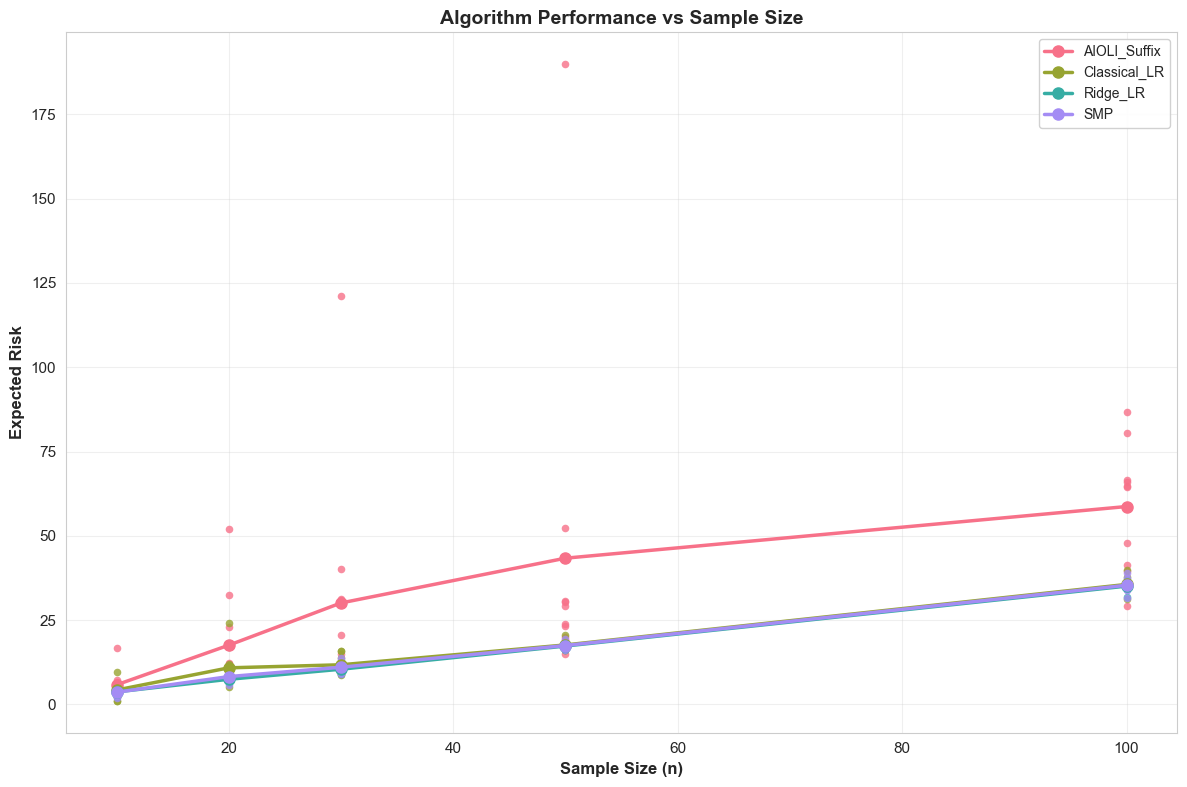

In [288]:
plot_simulation_results(summary_df= well_specified_changing_n[0],algorithms = ["AIOLI_Suffix","Classical_LR", "SMP", "Ridge_LR"] ,raw_data= well_specified_changing_n[1])

# Datasets

In [289]:

import kagglehub
import os

# Set cache to current directory
os.environ['KAGGLEHUB_CACHE'] = os.getcwd()

# Download latest version — returns the local path to the dataset folder
path = kagglehub.dataset_download("ashrafkhan94/oil-spill")
print("Dataset downloaded to:", path)
print("Files:", os.listdir(path)[0])  # inspect actual filename(s)
filename = os.listdir(path)[0]

Dataset downloaded to: C:\Users\marie\PycharmProjects\Thesis_Online-to-batch_Logistic-Regression\datasets\ashrafkhan94\oil-spill\versions\1
Files: oil-spill.csv


In [290]:
csv_file = os.path.join(path, filename)  # adjust name based on os.listdir(path) output
df = pd.read_csv(csv_file, header = None)

In [291]:
df = df.drop(df.columns[0],axis=1) # Remove first column because its for analysis based on the image number and its not one of the predictive variables.

In [292]:
df

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,49
0,2558,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,0.19,214.7,...,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95,1
1,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,901.7,...,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,0
2,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,86.1,...,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84,1
3,1201,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,166.5,...,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07,1
4,312,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,232.8,...,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,12,92.42,364.42,135,97200.0,59.42,10.34,884.0,0.17,110.0,...,381.84,254.56,84.85,146.97,4.50,0,2593.50,65.85,6.39,0
933,11,98.82,248.64,159,89100.0,59.64,10.18,831.0,0.17,107.2,...,284.60,180.00,150.00,51.96,1.90,0,4361.25,65.70,6.53,0
934,14,25.14,428.86,24,113400.0,60.14,17.94,847.0,0.30,133.9,...,402.49,180.00,180.00,0.00,2.24,0,2153.05,65.91,6.12,0
935,10,96.00,451.30,68,81000.0,59.90,15.01,831.0,0.25,97.5,...,402.49,180.00,90.00,73.48,4.47,0,2421.43,65.97,6.32,0


In [293]:
trialdata = generate_data("well specified")

500 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499


In [294]:
oil_x = df[df.columns[:-1]]

In [295]:
oil_y = df[df.columns[-1]]
oil_y.replace(0, -1, inplace=True)
oil_y

0      1
1     -1
2      1
3      1
4     -1
      ..
932   -1
933   -1
934   -1
935   -1
936   -1
Name: 49, Length: 937, dtype: int64

In [296]:
test_size = round(default_test_ratio*df.shape[0])
oil_x_train = oil_x[test_size:]
oil_y_train = oil_y[test_size:]
oil_x_test = oil_x[:test_size]
oil_y_test = oil_y[:test_size]

In [297]:
def evaluate_on_data(data_x,data_y):

    # Separate test and train
    test_size = round(default_test_ratio*data_x.shape[0])
    x_train = np.array(data_x[test_size:])
    y_train = np.array(data_y[test_size:])
    x_test = np.array(data_x[:test_size])
    y_test = np.array(data_y[:test_size])

    d = data_x.shape[1]

    # Run algorithms
    ## Get SMOTE dataset for unbalanced cases
    sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
    smote_x, smote_y = sm.apply_smote()

    ogd = online_gd(data_y=y_train, data_x=x_train, B=default_B)
    adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(5,d))
    aioli_model = AIOLI()
    ai = aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=default_B/13)
    classic_LR = classic_logistic_regression(data_x=x_train, data_y=y_train)
    ridge_LR = ridge_logistic_regression(data_x=x_train, data_y=y_train)
    lasso_LR = lasso_logistic_regression(data_x=x_train, data_y=y_train)
    smp = sample_minmax_predictor(x_train, y_train)
    ridge_smp = ridge_sample_minmax_predictor(x_train, y_train)
    classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)

    # OTB estimates
    # OGD
    OGD_OTB_uniform = calculate_OTB(ogd["All_Betas"], "uniform")
    OGD_OTB_Suffix  = calculate_OTB(ogd["All_Betas"], "suffix_averaging")
    OGD_OTB_lastit  = calculate_OTB(ogd["All_Betas"], "last_iterate")
    # AdaGrad
    adagrad_OTB_uniform = calculate_OTB(adagrad["All_Betas"], "uniform")
    adagrad_OTB_Suffix  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
    adagrad_OTB_lastit  = calculate_OTB(adagrad["All_Betas"], "last_iterate")

    ############################## TEST RESULTS ##############################
    # OGD
    loss_OGD_uniform_test = log_loss(OGD_OTB_uniform, x_test, y_test)
    loss_OGD_Suffix_test  = log_loss(OGD_OTB_Suffix,  x_test, y_test)
    loss_OGD_lastit_test  = log_loss(OGD_OTB_lastit,  x_test, y_test)

    # Adagrad
    loss_adagrad_uniform_test = log_loss(adagrad_OTB_uniform, x_test, y_test)
    loss_adagrad_Suffix_test  = log_loss(adagrad_OTB_Suffix,  x_test, y_test)
    loss_adagrad_lastit_test  = log_loss(adagrad_OTB_lastit,  x_test, y_test)

    # AIOLI
    loss_AIOLI_uniform_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
    loss_AIOLI_Suffix_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"]
    loss_AIOLI_lastit_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"]

    # Logistic Regression
    loss_LR_test = log_loss(classic_LR["Batch_estimate"], x_test, y_test)
    loss_LR_smote_test = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
    loss_LR_Ridge_test = log_loss(ridge_LR["Batch_estimate"],   x_test, y_test)
    loss_LR_Lasso_test = log_loss(lasso_LR["Batch_estimate"],   x_test, y_test)

    # SMP
    smp_result = smp.get_new_loss(x_test, y_test)
    ridge_smp_result = ridge_smp.get_new_loss(x_test, y_test)

    algorithms_test = {
        "Classical_LR":  {"loss": loss_LR_test},
        "Classical_LR_SMOTE":      {"loss": loss_LR_smote_test},
        "Ridge_LR":      {"loss": loss_LR_Ridge_test},
        "Lasso_LR":      {"loss": loss_LR_Lasso_test},
        "OGD_uniform": {"loss": loss_OGD_uniform_test},
        "OGD_Suffix":  {"loss": loss_OGD_Suffix_test},
        "OGD_Last_iterate": {"loss": loss_OGD_lastit_test},
        "AdaGrad_uniform": {"loss": loss_adagrad_uniform_test},
        "AdaGrad_Suffix":  {"loss": loss_adagrad_Suffix_test},
        "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test},
        "AIOLI_uniform": {"loss": loss_AIOLI_uniform_test},
        "AIOLI_Suffix":  {"loss": loss_AIOLI_Suffix_test},
        "AIOLI_lastit":  {"loss": loss_AIOLI_lastit_test},
        "SMP":      {"loss": smp_result["loss"]},
        "Ridge_SMP":      {"loss": ridge_smp_result["loss"]}
    }

    test_set_results = []
    for name, metrics in algorithms_test.items():
         test_set_results.append({
            "algorithm": name,
            **metrics
        })

    return {
            "test_results": pd.DataFrame(test_set_results)
        }


In [298]:
type(np.array(oil_x))

numpy.ndarray

In [299]:
# evaluate_on_data(oil_x,oil_y)

# Ignore from here on, it's simply code to test some functions/debugging

## Tests

In [300]:
#etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
#xt = np.array([1,2,3])
#betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
#reg_lambda = 0.3
#gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
#b = np.array([1,2,3])
#sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [301]:
#diff = b - betas
#inner_prod = np.sum(gradients * diff,axis = 1)
#np.sum(np.sum(etas)/2 * inner_prod**2)

In [302]:
# x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [303]:
# diff = b - betas
# gs_bs = np.sum(gradients * diff,axis = 1)
# quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)
#
# l_hat = sum_loss + np.sum(gs_bs) + quadratic
#
# l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

## Generate data

In [304]:
# n = 1000
#
# mean = [20, 5, 2]
# cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
# d = np.shape(cov)[1]
# y = np.random.binomial(n=1, p=0.3, size=n)
#
# x1, x2, x3 = np.random.multivariate_normal(mean, cov, size = n).T
# plt.plot(x1, x2, 'x')
# plt.axis('equal')
# plt.show()
#
# plt.plot(x1, x3, 'x')
# plt.axis('equal')
# plt.show()


In [305]:
# x = np.random.multivariate_normal(mean, cov, size = n)
# sns.countplot(x=y)
# plt.show()


In [306]:
# np.log(1000)

## OTB conversion proof tests

In [307]:
# weights = np.array([0.3,0.7])
# values = np.array([2,3])
#
# print(np.sum(values))
# print(np.sum(weights*values))